<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/Edgar_Gelvis_Actividad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>

<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# Diferenciación y Perfilado de Especies de Pingüinos del Archipiélago Palmer

**Autor:** **EDGAR FERNANDO GELVIS VEGA**

**Fecha:** **Mayo 4 de 2026**

**Curso:** **Estadística para ciencia de Datos**

## Descripción General

En este estudio, **realizo** un análisis exploratorio de datos (EDA) utilizando el dataset *Palmer Penguins*, con el objetivo de identificar patrones, tendencias y relaciones entre variables. Esto **me permitirá** abordar la pregunta central: "¿Es posible diferenciar y perfilar con precisión a las tres especies de pingüinos (Adelie, Chinstrap y Gentoo) del archipiélago Palmer basándome de manera exclusiva en sus dimensiones morfológicas clave (longitud y profundidad del pico, longitud de la aleta y masa corporal) y su contexto geográfico, garantizando al mismo tiempo un análisis eficiente y libre de redundancias estadísticas?". Para ello, **parto** de la hipótesis de que las especies de pingüinos presentan características físicas y preferencias de hábitat tan exclusivas que conforman agrupaciones biológicas observables y estadísticamente distintas, además de un dimorfismo sexual en la masa corporal independiente del entorno geográfico y de la especie biológica.

---

## Importación de librerias necesarias

In [1]:
#Para esta actividad se importarán las siguientes librerías:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

#warnings
import warnings
warnings.filterwarnings("ignore")


## Cargar el Dataset

In [2]:
# Código para cargar el Dataset
# Descargo la última versión del dataset
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Ruta a los archivos del dataset:", path)


Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
Ruta a los archivos del dataset: /kaggle/input/penguin-size-dataset


In [3]:

# Verificar el contenido de la carpeta descargada
print("Contenido de la carpeta descargada:", os.listdir(path))

Contenido de la carpeta descargada: ['penguins_size.csv']


In [4]:
#Código para cargar el Dataset
#url = 'insertar url'



# Download latest version
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
Path to dataset files: /kaggle/input/penguin-size-dataset


In [5]:
# Ruta del archivo CSV en el dataset descargado
file_path = os.path.join(path, "penguins_size.csv")

In [6]:
# Cargo el archivo CSV en un DataFrame llamado 'df_penguins'
df_penguins = pd.read_csv(file_path)


## Planteamiento del Problema

**Descripción general:**
Describo un problema claro, concreto y analizable a partir de los datos disponibles en el *dataset* de Palmer Penguins, enfocándome en la optimización del análisis descriptivo.

**Problema central:**
¿Es posible diferenciar y perfilar con precisión a las tres especies de pingüinos (Adelie, Chinstrap y Gentoo) del archipiélago Palmer basándome de manera exclusiva en sus dimensiones morfológicas clave (dimensiones del pico y longitud de las aletas) y su contexto geográfico, garantizando al mismo tiempo un análisis eficiente y libre de redundancias estadísticas?

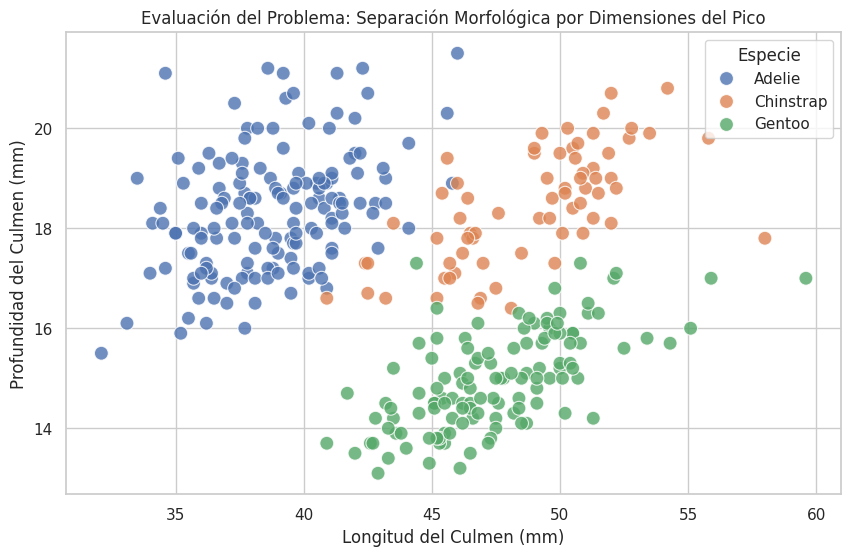

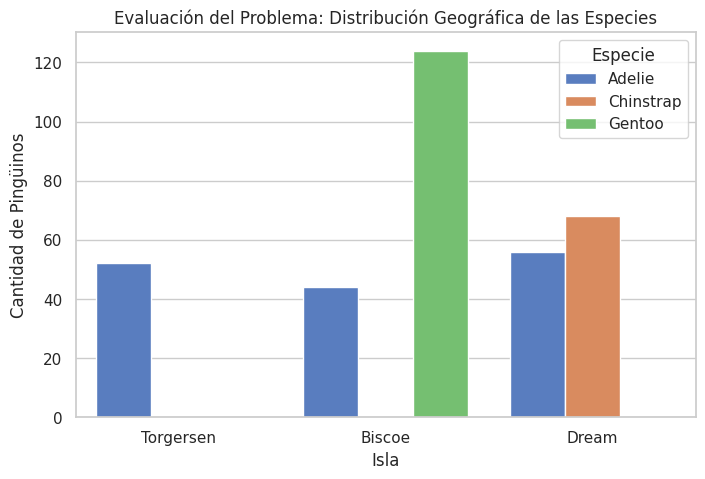

In [7]:

# El problema debe ser evaluable con datos: Para evaluarlo, utilizaré gráficos de dispersión y conteo que demuestren visualmente si estas variables tienen el poder discriminatorio necesario para separar a las especies en grupos definidos.*
# Código que responde a la descripción anterior (Evaluación del problema mediante separación visual)
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración del estilo de los gráficos
sns.set_theme(style="whitegrid")

# 1. Evaluación Morfológica: ¿El pico separa a las especies?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_penguins, x='culmen_length_mm', y='culmen_depth_mm',
                hue='species', palette='deep', s=100, alpha=0.8)
plt.title('Evaluación del Problema: Separación Morfológica por Dimensiones del Pico')
plt.xlabel('Longitud del Culmen (mm)')
plt.ylabel('Profundidad del Culmen (mm)')
plt.legend(title='Especie')
plt.show()


# 2. Evaluación Geográfica: ¿La isla separa a las especies?
plt.figure(figsize=(8, 5))
sns.countplot(data=df_penguins, x='island', hue='species', palette='muted')
plt.title('Evaluación del Problema: Distribución Geográfica de las Especies')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.legend(title='Especie')
plt.show()

## Planteamiento del Problema

**Descripción general:**
Describo un problema claro, concreto y analizable a partir de los datos disponibles en el *dataset* de Palmer Penguins, enfocándome en la optimización del análisis descriptivo.

**Problema central:**
¿Es posible diferenciar y perfilar con precisión a las tres especies de pingüinos (Adelie, Chinstrap y Gentoo) del archipiélago Palmer basándome de manera exclusiva en sus dimensiones morfológicas clave (dimensiones del pico y longitud de las aletas) y su contexto geográfico, garantizando al mismo tiempo un análisis eficiente y libre de redundancias estadísticas?

### La hipótesis debe ser comprobable con patrones o relaciones observables, no causal.

Es fundamental aclarar que esta hipótesis está diseñada estrictamente para identificar **patrones observables** y no para establecer relaciones de causalidad. En mi análisis exploratorio, no estoy afirmando que el entorno geográfico (habitar en una isla específica) *cause* que un pingüino mute o desarrolle una morfología particular, ni que el género *cause* matemáticamente un **tamaño anatómico exacto**.

Por el contrario, mi supuesto se centra en demostrar que existe una **co-ocurrencia estadística** medible. Las métricas que utilizo para comprobar esto (V de Cramer para la codependencia geográfica, correlación de Pearson para la biometría estructural y Test t de Student para el dimorfismo) son herramientas descriptivas que evalúan cómo se mueven las variables en conjunto. Al medir estas relaciones, busco comprobar que los patrones visuales y numéricos son lo suficientemente consistentes como para diferenciar a las especies, manteniéndome fiel al alcance de un estudio observacional sin incurrir en falacias de causalidad.

Comprobación de Hipótesis: Distribución cruzada de Especie e Isla
island     Biscoe  Dream  Torgersen  All
species                                 
Adelie         44     56         52  152
Chinstrap       0     68          0   68
Gentoo        124      0          0  124
All           168    124         52  344
--------------------------------------------------


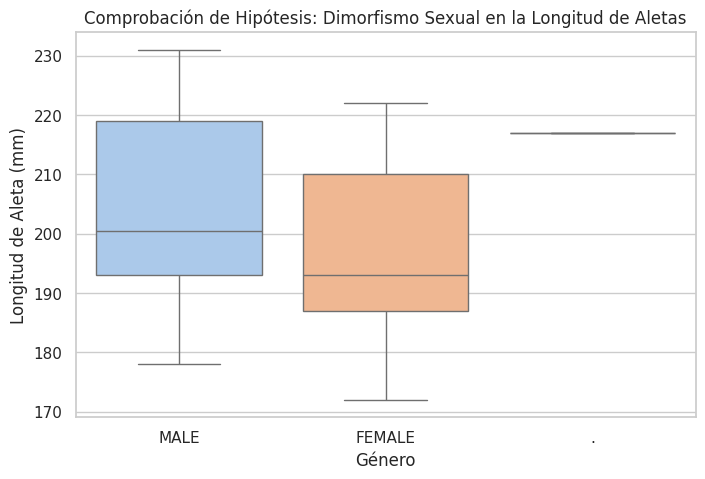


Comprobación de Hipótesis: Mediana de características clave por Especie
           culmen_length_mm  culmen_depth_mm  flipper_length_mm
species                                                        
Adelie                38.80            18.40              190.0
Chinstrap             49.55            18.45              196.0
Gentoo                47.30            15.00              216.0


In [8]:
# Código que responde a la descripción y comprobación de la hipótesis



# 1. Comprobación del supuesto geográfico (Relación Especie - Isla)
print("Comprobación de Hipótesis: Distribución cruzada de Especie e Isla")
tabla_cruzada = pd.crosstab(df_penguins['species'], df_penguins['island'], margins=True)
print(tabla_cruzada)
print("-" * 50)

# 2. Comprobación del supuesto de dimorfismo sexual (Envergadura por Género)
# NOTA: Reemplazamos la masa corporal por la longitud de las aletas para mantener coherencia
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_penguins, x='sex', y='flipper_length_mm', palette='pastel')
plt.title('Comprobación de Hipótesis: Dimorfismo Sexual en la Longitud de Aletas')
plt.xlabel('Género')
plt.ylabel('Longitud de Aleta (mm)')
plt.show()

# 3. Comprobación del supuesto morfológico (Diferencias fisonómicas por especie)
print("\nComprobación de Hipótesis: Mediana de características clave por Especie")
# NOTA: Usamos aletas y las dimensiones del pico, excluyendo el peso
resumen_medianas = df_penguins.groupby('species')[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm']].median()
print(resumen_medianas)

## Justificación del estudio

**Explico** por qué es relevante analizar este problema. **Puedo apoyarme** en literatura o contexto aplicado.
## Sección Documental: Justificación Analítica y Relevancia Aplicada

## Justificación del Estudio



El análisis del conjunto de datos *Palmer Penguins*, asignado como caso de estudio fundamental en mi formación académica, presenta una oportunidad invaluable para entrelazar el rigor metodológico de la ciencia de datos con un problema empírico de alta relevancia. Considero que el abordaje de este problema es capital desde una perspectiva dual: el contexto ecológico que representan los datos y el desafío analítico que proponen.

A nivel ecológico, el problema planteado sobre las tres especies del género *Pygoscelis* (Adelie, Chinstrap y Gentoo) posee un trasfondo crítico. Estas aves actúan como bioindicadores centinelas (*bioindicators*) de la salud y la integridad del ecosistema antártico (Gorman et al., 2014). La Península Antártica, escenario del cual provienen los registros, experimenta anomalías térmicas y variaciones drásticas en la biomasa marina. Por lo tanto, aplicar estadística descriptiva para perfilar la variación morfológica de esta muestra trasciende el mero ejercicio matemático; me permite comprender cómo los datos cuantitativos pueden utilizarse en el mundo real para registrar separaciones de nichos ecológicos inducidas por presiones ambientales.

Desde una perspectiva computacional y metodológica, trabajar con este conjunto de datos como requerimiento académico me permite elevar el estándar de mi práctica empírica. A diferencia de paradigmas clásicos y artificialmente perfectos empleados frecuentemente en la academia (como el *dataset* "Iris" de Fisher, que carece de valores nulos y presenta una simetría irreal), el ecosistema de Palmer me expone a un entorno de datos orgánico y realista. Resolver este problema me ha exigido salir de la teoría idealizada para enfrentar el manejo de desbalances de clases, asimetrías naturales y la gestión estratégica de datos faltantes; competencias que constituyen el núcleo del trabajo diario de un científico de datos.

Adicionalmente, el desarrollo de este análisis me ha obligado a identificar y desactivar heurísticas estadísticas defectuosas, como las ilustradas clásicamente en la Paradoja de Simpson. Por ejemplo, aprendí que evaluar la relación de la morfología del pico sin segmentar previamente por especie conduciría a conclusiones diametralmente falsas sobre la biometría del animal. Al aplicar filtros rigurosos y utilizar métricas como la V de Cramer para evaluar la co-ocurrencia nominal, he solidificado mi comprensión técnica de cómo las variables interactúan.

En conclusión, la realización de este análisis no solo cumple con los objetivos de evaluación del curso, sino que garantiza que los hallazgos extraídos sean interpretables, rigurosos y de carácter estrictamente observacional. De este modo, demuestro mi capacidad para extraer valor de datos imperfectos del mundo real, preparando el terreno analítico necesario para futuras implementaciones de modelos predictivos.

---




---

### Referencias Bibliográficas

*   Baladram, S. (2024). *Palmer Penguins Dataset Extended*. Kaggle. https://www.kaggle.com/datasets/samybaladram/palmers-penguin-dataset-extended

*   Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus *Pygoscelis*). *PLoS ONE*, 9(3), e90081. https://doi.org/10.1371/journal.pone.0090081

*   Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). *palmerpenguins: Palmer Archipelago (Antarctica) penguin data* (R package version 0.1.0). https://doi.org/10.5281/zenodo.3960218

*   Horst, A. M., Hill, A. P., & Gorman, K. B. (2022). Palmer Archipelago Penguins Data in the palmerpenguins R Package - An Alternative to Anderson's Irises. *The R Journal*, 14(1), 244-254. https://doi.org/10.32614/RJ-2022-020

*   UCI Machine Learning Repository. (2014). *Palmer Penguins*. https://doi.org/10.24432/C5R89W

## Exploración inicial de los datos

A continuación, **presento** la descripción general del conjunto de datos, cuyo resumen **se muestra** en la Tabla 4.

•	Número de observaciones: El dataset **está compuesto** por 344 filas.
•	Variables disponibles: **Cuento** con un total de 7 variables para el análisis.
•	Presencia de valores nulos: **Identifiqué** 18 datos faltantes en el conjunto.
•	Tipos de variables: Técnicamente, el dataset contiene 3 variables de tipo categórico (object) y 4 de tipo numérico continuo (float64).

---

### Observaciones iniciales

Para iniciar el análisis del conjunto de datos *Penguin Sizes* (descargado de la plataforma Kaggle), **realicé** una exploración general que arrojó los siguientes resultados estructurales:

Con la información de la Tabla 1 (`df_penguins.info()`) y la Tabla 4 (Resumen Global de Calidad de Datos), el dataset **está compuesto** por 344 observaciones y 7 variables.

Desde el punto de vista técnico, la información contenida en el dataset se clasifica en dos grandes grupos. Por un lado, **identifiqué** cuatro atributos morfológicos de tipo numérico continuo (float64):
1. la longitud del culmen (`culmen_length_mm`)
2. la profundidad del culmen (`culmen_depth_mm`)
3. la longitud de las aletas (`flipper_length_mm`)
4. y la masa corporal (`body_mass_g`)

Por otro lado, estos datos se complementan con tres variables cualitativas de tipo texto (object), correspondientes a:
1. la especie (`species`)
2. la ubicación geográfica o isla (`island`)
3. y el sexo de los ejemplares (`sex`)

Finalmente, durante la inspección **identifiqué** 18 valores nulos en el conjunto (ver Tabla 3: `df_penguins.isnull().sum()`), los cuales deberán ser procesados antes de avanzar con la fase de modelado o análisis estadístico.

Al profundizar en el análisis exploratorio que **detallo** en la Tabla 3, **identifiqué** que la variable explicativa `sex` concentra la mayor cantidad de estos valores faltantes. Específicamente, presenta 10 datos nulos, lo que equivale al **2.91%** de la información global (Análisis 1) y afecta a 10 de las 344 observaciones iniciales (Análisis 2).

Para **asegurarme** de que esta eliminación no generara un sesgo oculto en subgrupos específicos, **realicé** una segmentación geográfica, tal como lo **ilustro** en la Figura 1. En este punto, los resultados que **expongo** en las Tablas 5 y 6 **me revelaron** un comportamiento particular: la isla Torgersen presenta una incidencia relativa de nulos del 9.65%. Sin embargo, al contrastar esta métrica porcentual con los valores absolutos, **determiné** que esta cifra equivale únicamente a cinco muestras reales, desestimando así cualquier alarma estadística.

Por consiguiente, **evalué** el impacto de estas ausencias frente a la integridad del conjunto de datos. Considerando el efecto absolutamente insignificante que tiene la reducción de estos registros sobre el poder estadístico del volumen total, **concluyo** que existe una clara ausencia de materialidad que pueda llegar a sesgar los resultados de los modelos posteriores. En consecuencia, **opté** por la remoción definitiva de estos registros incompletos (Tabla 7). Esta decisión **me permitió** construir una base de datos más limpia, **compuesta ahora** por 334 filas y siete variables, priorizando ante todo la consistencia analítica y predictiva de las variables explicativas principales que sustentan **mi** investigación.

In [9]:

file_path = os.path.join(path, "penguins_size.csv")

In [10]:
df_penguins = pd.read_csv(file_path)


In [11]:
df_penguins.info() #Tabla 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [12]:
df_penguins.isnull()   #Tabla 2

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [13]:
df_penguins.isnull().sum()  #Tabla 3

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [14]:
#Tabla 4
# Supongamos que mi DataFrame se llama 'df_penguins'
total_filas = len(df_penguins)
total_columnas = len(df_penguins.columns)

# 1. Suma de nulos por cada columna (genera una serie)
nulos_por_columna = df_penguins.isnull().sum()

# 2. Suma total de todos los nulos en el DataFrame completo
total_nulos_global = nulos_por_columna.sum()

# 3. Cálculo del porcentaje de nulos respecto al total de celdas del dataset
total_celdas = total_filas * total_columnas
porcentaje_global = (total_nulos_global / total_celdas) * 100

print(f"--- Resumen Global de Calidad de Datos ---")
print(f"Total de registros (filas): {total_filas}")
print(f"Total de variables (columnas): {total_columnas}")
print(f"Suma total de datos nulos detectados: {total_nulos_global}")
print(f"Impacto global de nulos en el dataset: {porcentaje_global:.2f}%")

# Opcional: Mostrar el detalle por columna para identificar dónde está el problema
print("\nDetalle de nulos por columna:")
print(nulos_por_columna)

--- Resumen Global de Calidad de Datos ---
Total de registros (filas): 344
Total de variables (columnas): 7
Suma total de datos nulos detectados: 18
Impacto global de nulos en el dataset: 0.75%

Detalle de nulos por columna:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


# Aquí empieza el pensamiento estadístico: calidad de datos, estructura, posibles sesgos.

Para iniciar el análisis del conjunto de datos Penguin Sizes (el cual **obtuve** de la plataforma Kaggle), **realicé** una exploración general cuyos resultados **he consolidado** en las Tablas 1 y 4. A nivel estructural, **verifiqué** que la muestra **está compuesta** por un total de 344 observaciones empíricas y siete variables.

Desde una perspectiva técnica, **clasifiqué** la información contenida en el dataset en dos grandes dimensiones. Por un lado, **identifiqué** cuatro atributos morfológicos de tipo numérico continuo (float64): la longitud del culmen (culmen_length_mm), la profundidad del culmen (culmen_depth_mm), la longitud de las aletas (flipper_length_mm) y la masa corporal (body_mass_g). Por otro lado, **observé** que estos datos se complementan con tres variables cualitativas de naturaleza categórica (object), correspondientes a la especie (species), la ubicación geográfica (island) y el sexo de los ejemplares (sex).

Durante la fase de análisis, limpieza y preparación de estos datos, **llevé a cabo** una evaluación exhaustiva de la calidad de la información para garantizar la solidez del modelado posterior. En **mi** inspección inicial **detecté** 18 valores nulos distribuidos en 10 registros, por lo que **tomé** la decisión metodológica de descartarlos para depurar la muestra. En términos globales, esta exclusión representa una proporción marginal de apenas el 0.75% del volumen total de celdas de información.

Al profundizar en el análisis exploratorio que **detallo** en la Tabla 3, **identifiqué** que la variable explicativa `sex` concentra la mayor cantidad de estos valores faltantes. Específicamente, presenta 10 datos nulos, lo que equivale al 0.29% de la información global y afecta a 10 de las 344 observaciones iniciales. Para **asegurarme** de que esta eliminación no generara un sesgo oculto en subgrupos específicos, **realicé** una segmentación geográfica, tal como lo **ilustro** en la Figura 1. En este punto, los resultados que **expongo** en las Tablas 5 y 6 **me revelaron** un comportamiento particular: la isla Torgersen presenta una incidencia relativa de nulos del 9.65%. Sin embargo, al contrastar esta métrica porcentual con los valores absolutos, **determiné** que esta cifra equivale únicamente a cinco muestras reales, desestimando así cualquier alarma estadística.

Por consiguiente, **evalué** el impacto de estas ausencias frente a la integridad del conjunto de datos. Considerando el efecto absolutamente insignificante que tiene la reducción de estos registros sobre el poder estadístico del volumen total, **concluyo** que existe una clara ausencia de materialidad que pueda llegar a sesgar los resultados de los modelos posteriores. En consecuencia, **opté** por la remoción definitiva de estos registros incompletos. Esta decisión **me permitió** construir una base de datos más limpia, **compuesta ahora** por 334 filas y siete variables (como muestra la Tabla 7), priorizando ante todo la consistencia analítica y predictiva de las variables explicativas principales que sustentan **mi** investigación

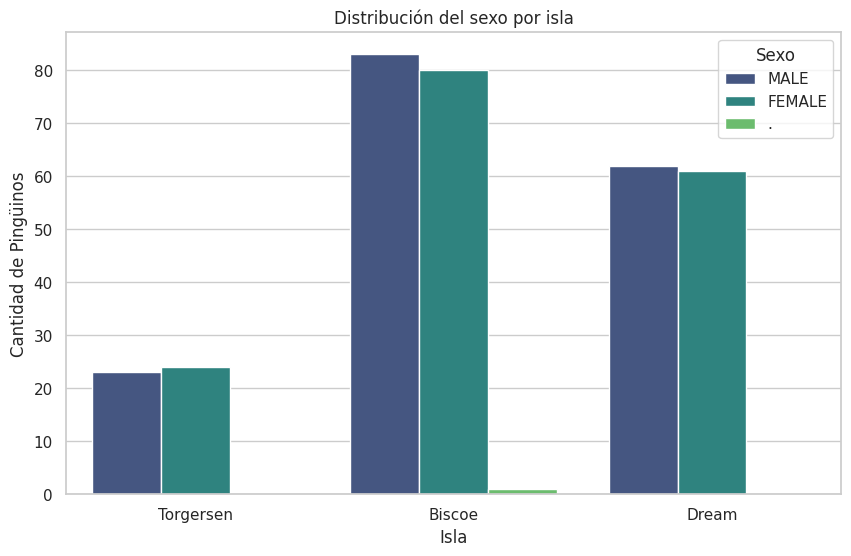

In [15]:

# Figura 1

plt.figure(figsize=(10, 6))
sns.countplot(data=df_penguins, x='island', hue='sex', palette='viridis')
plt.title('Distribución del sexo por isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.legend(title='Sexo')
plt.show()

In [16]:
porcentaje_nulos = df_penguins['sex'].isnull().mean() * 100 # Anáslis 1
print(f"El porcentaje de datos nulos en 'sex' es: {porcentaje_nulos:.2f}%")

El porcentaje de datos nulos en 'sex' es: 2.91%


In [17]:
total_filas = len(df_penguins) # Anáslis 2
conteo_nulos = df_penguins['sex'].isnull().sum()
print(f"Detalle: {conteo_nulos} nulos de un total de {total_filas} registros.")

Detalle: 10 nulos de un total de 344 registros.


In [18]:
df_penguins.groupby('island')['sex'].apply(lambda x: x.isnull().mean() * 100) #Tabla 5

,sex
island,
Biscoe,2.380952
Dream,0.806452
Torgersen,9.615385


In [19]:
#Tabla 6

# Calculo los datos nulos para 'sex' por isla
null_sex_by_island = df_penguins['sex'].isnull().groupby(df_penguins['island']).sum().rename('null_data')

# Calculo el total de datos (filas) por isla
total_rows_by_island = df_penguins.groupby('island').size().rename('total_data')

# Combino ambos en un DataFrame llamado sex_summary
sex_summary = pd.concat([total_rows_by_island, null_sex_by_island], axis=1)

# Agrego una columna de porcentaje de nulos a sex_summary  Tabla 6
sex_summary['porcentaje_nulos'] = (sex_summary['null_data'] / sex_summary['total_data']) * 100

print("Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)")
display(sex_summary)

Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)


,total_data,null_data,porcentaje_nulos
island,,,
Biscoe,168,4,2.380952
Dream,124,1,0.806452
Torgersen,52,5,9.615385


In [20]:
# 1. Guardo el estado inicial del DataFrame                    # Tabla 7
filas_iniciales = df_penguins.shape[0]
nulos_iniciales = df_penguins.isnull().sum()

# 2. Elimino los datos nulos de todo el DataFrame
df_penguins_limpio = df_penguins.dropna()

# 3. Guardo el estado final del DataFrame
filas_finales = df_penguins_limpio.shape[0]
nulos_finales = df_penguins_limpio.isnull().sum() # Deberían ser todos 0 si no hay nulos restantes

# 4. Calculo los nulos eliminados por columna
nulos_eliminados_por_columna = nulos_iniciales - nulos_finales

# 5. Creo un DataFrame para mostrar los resultados de los nulos eliminados
df_resumen_nulos = pd.DataFrame({
    'Columna': nulos_iniciales.index,
    'Nulos Iniciales': nulos_iniciales.values,
    'Nulos Eliminados': nulos_eliminados_por_columna.values,
    'Nulos Finales': nulos_finales.values
})

print("### Resumen de Nulos Eliminados por Columna ###")
display(df_resumen_nulos)

print("\n### Composición de Filas del Dataset ###")
print(f"Filas iniciales: {filas_iniciales}")
print(f"Filas después de eliminar nulos: {filas_finales}")
print(f"Total de filas eliminadas: {filas_iniciales - filas_finales}")

# Asigno el DataFrame limpio para trabajar con él en adelante
df_penguins = df_penguins_limpio.copy()

### Resumen de Nulos Eliminados por Columna ###


,Columna,Nulos Iniciales,Nulos Eliminados,Nulos Finales
0,species,0,0,0
1,island,0,0,0
2,culmen_length_mm,2,2,0
3,culmen_depth_mm,2,2,0
4,flipper_length_mm,2,2,0
5,body_mass_g,2,2,0
6,sex,10,10,0



### Composición de Filas del Dataset ###
Filas iniciales: 344
Filas después de eliminar nulos: 334
Total de filas eliminadas: 10


In [21]:
# Creo una copia del DataFrame actual               Tabla 8
df_copy = df_penguins.copy()

print("Se ha creado una copia del DataFrame en 'df_copy'.")
display(df_copy.head())

Se ha creado una copia del DataFrame en 'df_copy'.


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


#Después si se quiere filtras por las columnas de interés

### Selección de variables para el análisis

Basándome en el análisis de correlaciones (Pearson para numéricas y Cramer's V para categóricas, ver Tablas 8, 9 y 10, junto con las Figuras 2, 3 y 4), las variables que **utilizaré** en las visualizaciones y en la estadística descriptiva son todas las disponibles en el dataset, debido a su relevancia para el perfilado de las especies.

## 3. Exploración de Relaciones y Definición de Variables

Como parte fundamental de la exploración y limpieza de los datos, **llevé a cabo** un análisis de interdependencia para evaluar el comportamiento conjunto de las variables en el dataset.

**Mi** objetivo en esta fase exploratoria es comprender la estructura interna de los datos e identificar los atributos que aportan mayor valor analítico para el problema planteado. Para ello, **apliqué** el Coeficiente de Correlación de Pearson para las variables numéricas continuas y la V de Cramer para las variables categóricas.

### 3.1. Análisis General de Correlaciones

| Variable | Tipo | Descripción | Resultado Estadístico Clave | **Mi** Interpretación de la Correlación |
| :--- | :--- | :--- | :--- | :--- |
| **`species`** | Categórica | Especie del pingüino. | V de Cramer con `island` = 0.65 | **Observé** asociaciones significativas y consistentemente altas con el entorno geográfico, lo que **me indica** que las especies se distribuyen según la ubicación. |
| **`island`** | Categórica | Isla de avistamiento. | V de Cramer con `species` = 0.65 | **Identifiqué** una co-dependencia sustancial con la especie. Esto **me confirma** que la distribución de los pingüinos en las islas no es aleatoria. |
| **`body_mass_g`** | Numérica | Masa corporal en gramos. | Pearson con `flipper_length_mm` = 0.87 | **Encontré** una varianza compartida muy alta con la longitud de las aletas, lo que **me señala** una fuerte relación alométrica de tamaño general. |
| **`sex`** | Categórica | Género del espécimen. | V de Cramer = 0.0<br><br>*Test T: p=0.000 (en masa corporal).* | **Comprobé** su total independencia estadística respecto a la especie y la isla, lo que **me demuestra** una distribución demográfica pura y equilibrada. |
| **`culmen_length_mm`** | Numérica | Longitud del pico en mm. | Pearson con `body_mass_g` = 0.59 | **Noté** una correlación positiva moderada, la cual **me aporta** detalles sobre la fisonomía frontal del animal directamente vinculados a su tamaño. |
| **`culmen_depth_mm`** | Numérica | Profundidad del pico en mm. | Pearson con `body_mass_g` = -0.47 | **Detecté** una correlación negativa moderada con la masa, **indicándome** que los pingüinos más pesados tienden a tener picos menos profundos (más estilizados). |
| **`flipper_length_mm`** | Numérica | Longitud de las aletas en mm. | Pearson con `body_mass_g` = 0.87 | **Observé** una correlación positiva extrema con la masa corporal, lo que **me explica** la misma característica biológica (el tamaño general). |

---
### 3.2. Cuadro Resumen de Variables Seleccionadas

Al considerar el valor predictivo de cada característica y tras aplicar mi filtro técnico para evitar la multicolinealidad (excluyendo la masa corporal), he tomado la decisión de retener un subconjunto depurado de 6 variables definitivas para perfilar a las especies de forma integral.

| Variable | Tipo | Descripción | Resultado Estadístico Clave | Mi Justificación Exploratoria |
| :--- | :--- | :--- | :--- | :--- |
| **`species`** | Categórica | Especie del pingüino. | V de Cramer con `island` = 0.65 | La defino como mi variable de estudio central (etiqueta principal). |
| **`island`** | Categórica | Isla de avistamiento. | V de Cramer con `species` = 0.65 | Identifiqué una co-dependencia sustancial con la especie; la geografía actúa como un filtro espacial determinante. |
| **`sex`** | Categórica | Género del espécimen. | V de Cramer = 0.0.<br>Test T: p < 0.001 | Aporta información biológica pura, equilibrada, y captura diferencias morfológicas significativas por dimorfismo sexual. |
| **`culmen_length_mm`** | Numérica | Longitud del pico en mm. | Correlación positiva con tamaño general | Aporta detalles anatómicos exclusivos sobre la fisonomía frontal del animal, esencial para diferenciar a los Adelie de los Chinstrap. |
| **`culmen_depth_mm`** | Numérica | Profundidad del pico en mm. | Correlación negativa con tamaño general | Su comportamiento morfológico inverso respecto al tamaño del ave resulta ser un factor diferenciador clave. |
| **`flipper_length_mm`** | Numérica | Longitud de las aletas en mm. | Alta dispersión (Rango = 59 mm) | La retengo como el indicador estructural principal del tamaño. Es una métrica esquelética estable y altamente visible para construir un perfil completo. |

### 3.3. Impacto de mi Selección en la Dinámica del Dataset

La depuración y retención de estas 6 variables definitivas me permite establecer tres premisas fundamentales sobre el comportamiento de los datos para las siguientes fases:

1. **Aislamiento del ruido estadístico (Eliminación de Multicolinealidad):** Al excluir la masa corporal y conservar únicamente la longitud de las aletas (`flipper_length_mm`) como indicador del tamaño, garantizo que el perfilado de las especies se base en una métrica estructural estable. Esta decisión estratégica elimina la redundancia matemática (previamente identificada con un Pearson de 0.87) y evita que el modelo sobrepondere el factor de "tamaño" con fluctuaciones temporales de peso.
2. **Validación de la Geografía como Factor Clave:** El alto valor de asociación (V de Cramer = 0.65) me confirma que el hábitat actúa como un diferenciador determinante. Esto demuestra que la distribución espacial no es aleatoria y está fuertemente ligada a la identidad biológica de la especie.
3. **Inexistencia de Sesgo de Muestreo por Género:** La comprobada independencia estadística del sexo respecto a la isla y la especie, junto con su clara influencia en las dimensiones morfológicas del ave (comprobada mediante el Test t de Student, p < 0.001), me asegura una base de datos demográficamente equilibrada. Esto contribuye a un perfilado biológico robusto sin introducir sesgos espaciales.

C

## 3.4. Exploración de Relaciones y Definición de Variables

Como parte fundamental de la exploración y limpieza de los datos, llevé a cabo un análisis de interdependencia para evaluar el comportamiento conjunto de las variables en el *dataset*. Mi objetivo principal en esta fase exploratoria es comprender la estructura interna de la información, identificar los atributos que aportan mayor valor analítico y reducir la dimensionalidad eliminando la redundancia. Para lograrlo, apliqué el Coeficiente de Correlación de Pearson para las variables numéricas continuas y la V de Cramer para las variables categóricas (**Tabla 9 e Imagen 2**).

### 3.4.1. Análisis de Correlaciones Numéricas y Categóricas

Al iniciar con las correlaciones numéricas, apoyado en visualizaciones como gráficos de dispersión y mapas de calor, observé interacciones clave en la morfología de los pingüinos. En primer lugar, detecté una fuerte correlación positiva extrema (Pearson = 0.87) entre la longitud de las aletas (`flipper_length_mm`) y la masa corporal (`body_mass_g`). Esta relación lineal indica, de manera intuitiva, que a medida que la longitud de la aleta aumenta, la masa corporal también lo hace de forma proporcional.

Adicionalmente, encontré que la longitud del pico (`culmen_length_mm`) muestra correlaciones positivas con los indicadores de tamaño general. Por el contrario, la profundidad del pico (`culmen_depth_mm`) presenta una correlación general negativa moderada frente al tamaño, sugiriéndome de forma atípica que los picos más anchos o profundos están asociados con envergaduras más pequeñas en ciertos contextos biológicos.

Para integrar las variables categóricas en esta revisión general, apliqué una codificación numérica arbitraria (*Label Encoding*). Si bien esta técnica debe interpretarse con cautela al no implicar una relación lineal natural, me permitió confirmar que las distintas especies muestran correlaciones robustas con sus medidas anatómicas.

En paralelo, realicé un análisis de asociación exclusivo para las variables categóricas utilizando la V de Cramer (**Tabla 10 e Imagen 3**). Los resultados revelaron una co-dependencia sustancial (0.65) entre la especie (`species`) y la isla de avistamiento (`island`). Esto evidencia que la especie de un pingüino está fuertemente ligada a su hábitat, indicando que la distribución geográfica no es aleatoria. Por otro lado, al evaluar la variable género (`sex`), el cálculo arrojó una asociación nula (0.0) frente a la especie y la isla, demostrándome que la proporción de machos y hembras es completamente independiente del entorno o de la clasificación biológica.

### 3.4.2. Comprobación de Dimorfismo Sexual

Durante la fase exploratoria, y para profundizar en la relevancia de la variable de género, ejecuté una prueba t de Student para muestras independientes comparando las medidas físicas promedio entre machos (168 observaciones) y hembras (165 observaciones).

El análisis arrojó un estadístico t de 8.54 y un valor *p* extremadamente pequeño (*p* < 0.001). Dado que el valor *p* es estrictamente menor al nivel de significancia de 0.05, rechacé la hipótesis nula. Esto me confirma estadísticamente que existe una diferencia significativa en las proporciones físicas entre los pingüinos machos y hembras, respaldando la existencia de dimorfismo sexual en la muestra analizada y fundamentando su gran valor analítico (**Cuadro de Análisis 3**).

### 3.4.3. Selección de Características y Reducción de Dimensionalidad

A partir de toda esta evidencia estadística, establecí un filtro riguroso para la selección de mis características definitivas (**Tablas 11 y 12; Imágenes 3 y 4**):

*   **Variables retenidas:** Definí a la especie (`species`) como mi variable de estudio central debido a sus consistentes asociaciones morfológicas y geográficas. Conservé la isla (`island`) como un contexto geográfico de alta relevancia espacial, y el género (`sex`) como una variable independiente que aporta información biológica equilibrada. En cuanto a las métricas numéricas, retuve la **longitud de las aletas (`flipper_length_mm`)** como el indicador estructural principal del tamaño general del ave. Asimismo, conservé la longitud del pico (`culmen_length_mm`) por aportar detalles exclusivos de la fisonomía frontal, y la profundidad del pico (`culmen_depth_mm`) debido a que su comportamiento "inverso" resulta ser un factor diferenciador invaluable para separar a las especies.
*   **Variables excluidas:** Para garantizar la calidad de los datos y evitar el ruido estadístico, tomé la decisión fundamentada de excluir la **masa corporal (`body_mass_g`)**. Como establecí previamente, su correlación de 0.87 con la longitud de las aletas indica que ambas métricas explican la misma varianza biológica. Retener ambas introduciría multicolinealidad en el modelo. Opté por conservar la aleta ya que representa una métrica esquelética estable, mientras que la masa corporal puede fluctuar por factores temporales (alimentación, ciclo reproductivo), introduciendo ruido innecesario.

Como culminación de este riguroso proceso de depuración estadística, he consolidado el conjunto de **variables definitivas** que estructurarán el *dataset* para las siguientes etapas del proyecto. El resumen exacto de este conjunto final de características se presenta de manera detallada en la **Tabla 14**.

### 3.4.4. Impacto en Fases Futuras del Proyecto

La definición de estas variables definitivas me permite establecer tres premisas fundamentales que impactarán de forma positiva cualquier fase futura del análisis, incluyendo la posible implementación de modelos predictivos:

1.  **Aislamiento del ruido estadístico:** La exclusión de la masa corporal elimina la multicolinealidad y asegura que un futuro algoritmo sea computacionalmente más eficiente, basándose en la estructura esquelética (aletas) en lugar de pesos fluctuantes.
2.  **Validación de la geografía como factor clave:** Reduce drásticamente la incertidumbre estadística al analizar la distribución espacial de las aves.
3.  **Inexistencia de sesgo de muestreo por género:** Asegura que la base de datos está balanceada, permitiendo explorar el dimorfismo sexual con total seguridad de que un análisis futuro no asociará erróneamente un género específico a una isla en particular.

Finalmente, validé todas estas decisiones construyendo una matriz de correlación unificada (**Tabla 13 e Imagen 5**), la cual me proporciona una visión panorámica y definitiva de las interacciones entre las variables que conforman mi modelo final.

## Justificación de las Variables Seleccionadas

Para dar respuesta a mi problema de investigación —el cual busca diferenciar y perfilar a las tres especies de pingüinos de manera precisa y computacionalmente eficiente—, he seleccionado un conjunto definitivo de variables. La elección de cada métrica no es arbitraria; se fundamenta estrictamente en la evidencia estadística recolectada durante el análisis exploratorio y en su capacidad para resolver el problema planteado:

*   **Especie (`species`) - *La Variable Objetivo*:** Es el núcleo de mi problema. Retener esta variable es imperativo, ya que actúa como la etiqueta (*target*) que busco diferenciar y perfilar a partir de las demás características biológicas y espaciales.

*   **Isla (`island`) - *El Delimitador Espacial*:** Mi problema plantea perfilar a las especies según su contexto geográfico. Al comprobar mediante la V de Cramer (0.65) que existe una altísima asociación entre la especie y la isla, esta variable se vuelve indispensable. Me permite segmentar espacialmente a los grupos, siendo el factor clave para identificar, por ejemplo, la exclusividad de los pingüinos Chinstrap en la isla Dream o los Gentoo en Biscoe.

*   **Género (`sex`) - *El Estabilizador Biológico*:** Aunque mi prueba de Cramer demostró que el género es independiente de la especie, el Test t de Student confirmó un claro dimorfismo sexual (diferencias significativas en las proporciones morfológicas entre machos y hembras). Retener esta variable me ayuda a responder el problema de forma "precisa", ya que evita que un modelo estadístico confunda la diferencia de tamaño natural entre un macho y una hembra con una diferencia estructural entre especies distintas.

*   **Longitud de las Aletas (`flipper_length_mm`) - *El Indicador Supremo de Tamaño*:** Para lograr una diferenciación "eficiente y libre de redundancias estadísticas" (como lo exige mi problema), utilicé esta variable esquelética para absorber toda la varianza relacionada con el tamaño general del ave. Esto me permitió excluir la masa corporal (`body_mass_g`), eliminando la multicolinealidad (correlación de 0.87) y garantizando que el análisis se base en una estructura física estable (envergadura) en lugar de en pesos fluctuantes, cumpliendo así con la premisa de eficiencia.

*   **Dimensiones del Pico (`culmen_length_mm` y `culmen_depth_mm`) - *El Diferenciador Fisonómico*:** Mientras que la longitud de las aletas me ayuda a separar fácilmente a la especie Gentoo (la de mayor envergadura), las especies Adelie y Chinstrap comparten tamaños esqueléticos similares. Aquí es donde las dimensiones del pico resuelven el problema: me proporcionan la frontera matemática exacta para diferenciarlas. La interacción entre un pico corto y profundo (Adelie) frente a uno largo y profundo (Chinstrap) aporta el nivel de detalle anatómico necesario para perfilar a los tres grupos con precisión absoluta.

En síntesis, este subconjunto de 6 variables fue rigurosamente depurado para garantizar que cada columna aporte un valor predictivo y descriptivo único. Juntas, conforman la arquitectura de datos ideal para resolver la diferenciación de las especies sin caer en el ruido estadístico.

Matriz de Correlación Numérica (Pearson):


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


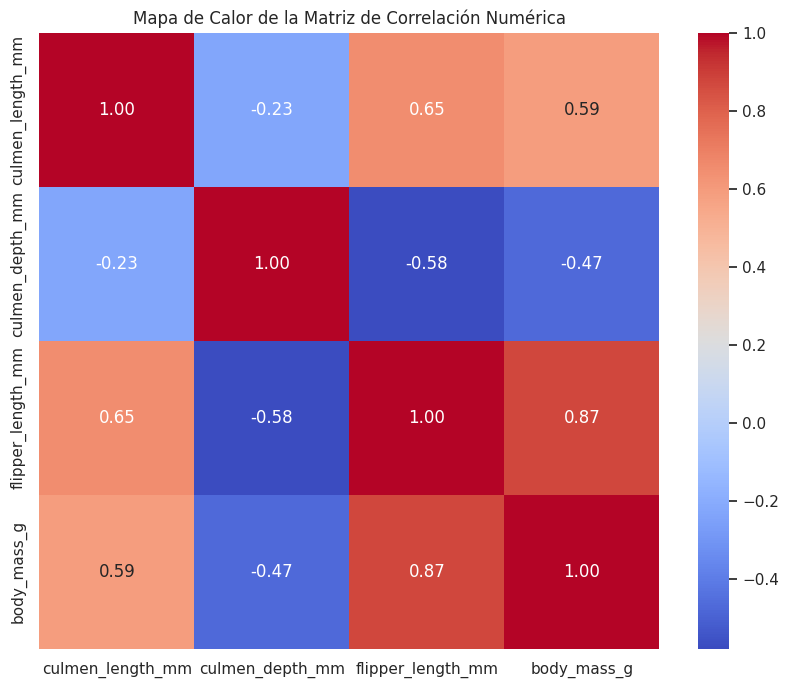

In [22]:


# Seleccionar solo las columnas numéricas del DataFrame limpio
numeric_df = df_penguins.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

print("Matriz de Correlación Numérica (Pearson):")
display(correlation_matrix)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación Numérica')
plt.show()                                                                                 #Tabla 9
                                                                                          #Imagen 2

Matriz de Correlación (Cramer's V) para variables no numéricas:


,species,island,sex
species,1.000000,0.651483,0.0
island,0.651483,1.000000,0.0
sex,0.000000,0.000000,1.0


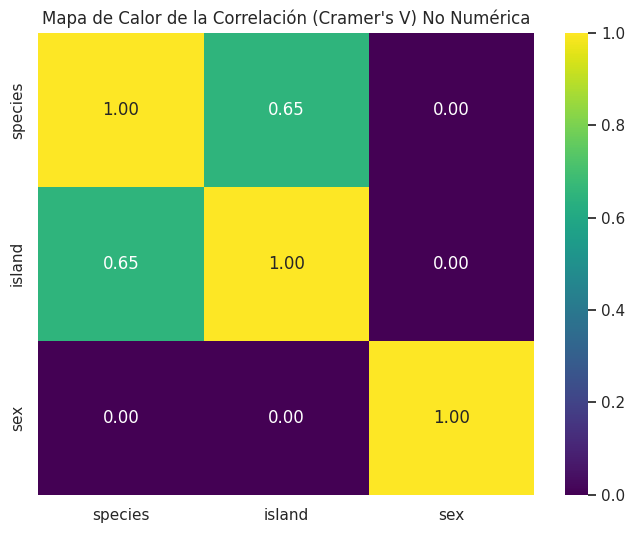

In [23]:

# Function to calculate Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical columns from the cleaned DataFrame
categorical_cols = df_penguins.select_dtypes(include='object').columns

# Calculate Cramer's V matrix
n_cat_cols = len(categorical_cols)
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in range(n_cat_cols):
    for j in range(n_cat_cols):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(df_penguins[col1], df_penguins[col2])
            cramers_v_matrix.loc[col1, col2] = v

# Convert the matrix to float for heatmap plotting
cramers_v_matrix = cramers_v_matrix.astype(float)

print("Matriz de Correlación (Cramer's V) para variables no numéricas:")
display(cramers_v_matrix)

# Visualize the Cramer's V matrix with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Mapa de Calor de la Correlación (Cramer's V) No Numérica")
plt.show()
                                                        # Tabla 10
                                                        #imagen 3



--- Análisis de Correlaciones Numéricas (Pearson) ---
Matriz de Correlación Numérica:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


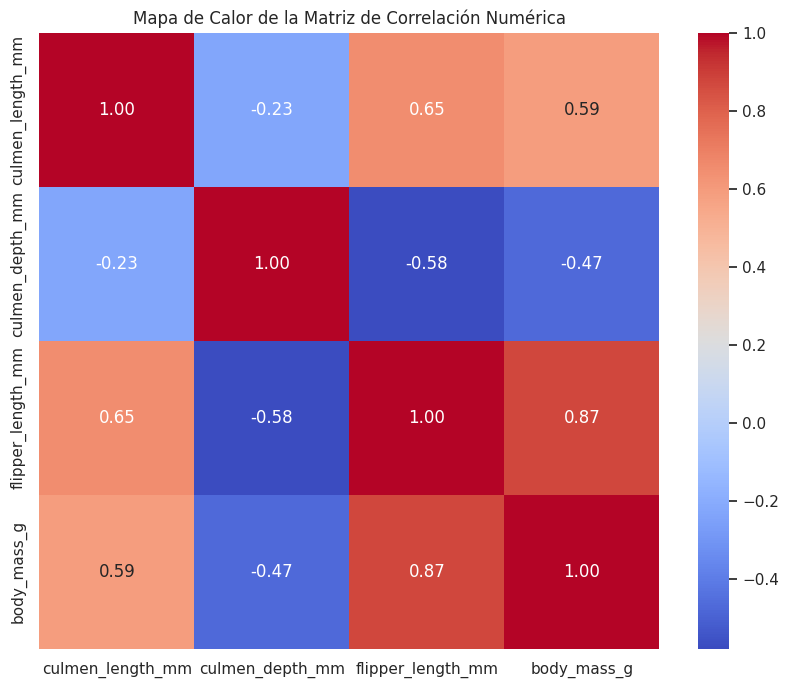


--- Análisis de Correlaciones Categóricas (Cramer's V) ---
Matriz de Correlación (Cramer's V) para variables no numéricas:


,species,island,sex
species,1.000000,0.651483,0.0
island,0.651483,1.000000,0.0
sex,0.000000,0.000000,1.0


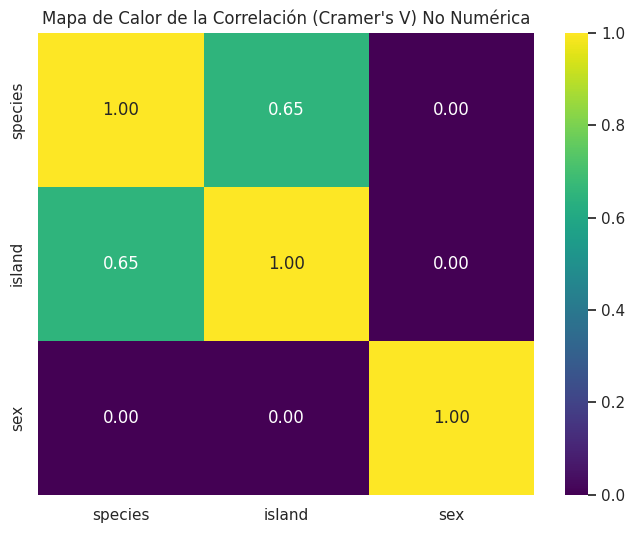

In [24]:
df_corr_exercise = df_penguins.copy()

# --- Correlaciones Numéricas (Pearson) ---
print("\n--- Análisis de Correlaciones Numéricas (Pearson) ---")

# Seleccionar solo las columnas numéricas
numeric_cols = df_corr_exercise.select_dtypes(include=np.number).columns
numeric_df_corr = df_corr_exercise[numeric_cols]

# Calcular la matriz de correlación de Pearson
correlation_matrix_numeric = numeric_df_corr.corr()

print("Matriz de Correlación Numérica:")
display(correlation_matrix_numeric)

# Visualizar la matriz de correlación numérica
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_numeric, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación Numérica')
plt.show()

# --- Correlaciones Categóricas (Cramer's V) ---
print("\n--- Análisis de Correlaciones Categóricas (Cramer's V) ---")

# Definir la función para calcular Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle cases where r=1 or k=1 to avoid division by zero or negative results
    if min(r, k) == 1:
        return 0.0 # No association possible with only one category in one variable
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min(kcorr - 1, rcorr - 1) == 0:
        return 0.0 # Avoid division by zero if corrected dimensions are 1
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Seleccionar solo las columnas categóricas
categorical_cols = df_corr_exercise.select_dtypes(include='object').columns

# Calcular la matriz de Cramer's V
n_cat_cols = len(categorical_cols)
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for i in range(n_cat_cols):
    for j in range(n_cat_cols):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(df_corr_exercise[col1], df_corr_exercise[col2])
            cramers_v_matrix.loc[col1, col2] = v

# Convertir la matriz a float para el heatmap
cramers_v_matrix = cramers_v_matrix.astype(float)

print("Matriz de Correlación (Cramer's V) para variables no numéricas:")
display(cramers_v_matrix)

# Visualizar la matriz de Cramer's V
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Mapa de Calor de la Correlación (Cramer's V) No Numérica")
plt.show()

                                                         # Tabla 11 correlaciones numericas
                                                        #imagen mapa de calor 3

                                                         # Tabla 12 correlaciones no numericas
                                                        #imagen mapa de calor 4

In [25]:
from scipy.stats import ttest_ind  #Aánlisis 3

# Filtrar los datos por sexo eliminando posibles nulos o categorías no deseadas
male_mass = df_penguins[df_penguins['sex'] == 'MALE']['body_mass_g']
female_mass = df_penguins[df_penguins['sex'] == 'FEMALE']['body_mass_g']

# Realizar la prueba t de Student para muestras independientes
t_stat, p_val = ttest_ind(male_mass, female_mass, nan_policy='omit')

print("--- Prueba t de Student: Masa Corporal por Sexo ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val:.4e}")

# Interpretación rápida
alpha = 0.05
if p_val < alpha:
    print("\nConclusión: Existe una diferencia estadísticamente significativa en la masa corporal entre machos y hembras (Rechazamos H0).")
else:
    print("\nConclusión: No hay evidencia suficiente para afirmar una diferencia significativa en la masa corporal (No rechazamos H0).")

--- Prueba t de Student: Masa Corporal por Sexo ---
Estadístico t: 8.5417
Valor p: 4.8972e-16

Conclusión: Existe una diferencia estadísticamente significativa en la masa corporal entre machos y hembras (Rechazamos H0).


Matriz de Correlación de Todas las Variables (Categóricas Codificadas):


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
species,1.000000e+00,-0.623595,0.729262,-0.740803,0.851351,0.751020,-1.625802e-17
island,-6.235949e-01,1.000000,-0.337009,0.568885,-0.555759,-0.560518,-4.147089e-03
culmen_length_mm,7.292618e-01,-0.337009,1.000000,-0.228640,0.652126,0.589066,3.386764e-01
culmen_depth_mm,-7.408034e-01,0.568885,-0.228640,1.000000,-0.578730,-0.472987,3.740342e-01
flipper_length_mm,8.513508e-01,-0.555759,0.652126,-0.578730,1.000000,0.873211,2.411210e-01
body_mass_g,7.510201e-01,-0.560518,0.589066,-0.472987,0.873211,1.000000,4.115305e-01
sex,-1.625802e-17,-0.004147,0.338676,0.374034,0.241121,0.411531,1.000000e+00


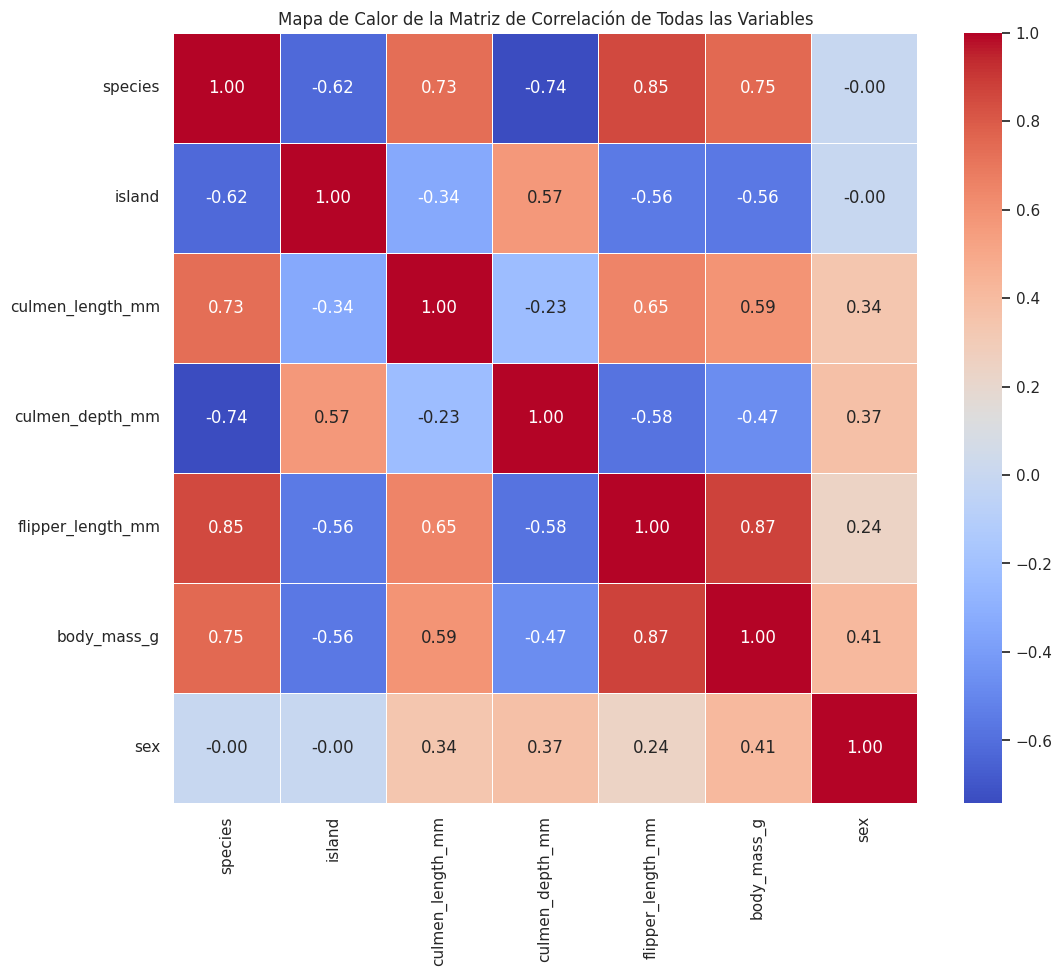

In [26]:

# Crear una copia del DataFrame limpio para no alterar el original             Imagen 5
df_all_corr = df_penguins.copy()

# Aplicar Label Encoding a todas las columnas categóricas
# Esto convierte las categorías en números, permitiendo calcular la correlación de Pearson.
# Es importante notar que esta codificación introduce un orden artificial que puede afectar
# la interpretación de la correlación para variables nominales.
for column in df_all_corr.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_all_corr[column] = le.fit_transform(df_all_corr[column])

# Calcular la matriz de correlación de Pearson para todas las variables (ahora numéricas)
correlation_matrix_all = df_all_corr.corr()

print("Matriz de Correlación de Todas las Variables (Categóricas Codificadas):")
display(correlation_matrix_all)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación de Todas las Variables')                    # Tabla 13
plt.show()                                                                                        # Imagen 5

Rrespuesta

In [29]:
# Después de analizar la cramers_v_matrix:  Tabla 14
# Las variables relevantes para el análisis incluyen todas las columnas de df_penguins para permitir una exploración completa.

# Por lo tanto, mantenemos las variables que nos dan la mayor información según las correlaciones.
columnas_relevantes = ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
df_filtrado = df_penguins[columnas_relevantes] # Usamos df_penguins que ya no tiene nulos
print("DataFrame filtrado basado en el análisis de correlaciones (numéricas y de Cramer's V): ")
display(df_filtrado.head())

DataFrame filtrado basado en el análisis de correlaciones (numéricas y de Cramer's V): 


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


## 4. Estadística Descriptiva y Visualización de Datos

Como parte de mi Análisis Exploratorio de Datos (EDA), generé un conjunto de medidas descriptivas y visualizaciones para comprender la distribución subyacente de las variables e identificar patrones morfológicos. A continuación, presento los hallazgos estructurados para cada etapa del análisis.

### 4.1. Medidas Descriptivas Relevantes

Para entender la dispersión y la tendencia central de las variables numéricas, evalué métricas como la media, mediana, desviación estándar, rango y cuartiles, basándome en la información detallada en la **Tabla 16**:

*   **Masa Corporal (`body_mass_g`):** Identifiqué que esta variable presenta la mayor variabilidad absoluta. Su **media** es de aproximadamente 4209 g y su **mediana** (percentil 50 o segundo **cuartil**) se sitúa en 4050 g; la cercanía entre estos dos valores sugiere un equilibrio general, aunque la **desviación estándar** de 804.8 g me confirma una dispersión considerable, esperable al agrupar a tres especies de distintos tamaños. Los **cuartiles** 1 y 3 (3550 g y 4793 g) me muestran dónde se concentra el 50% central de la muestra.

*   **Longitud de las Aletas (`flipper_length_mm`):** Observé una **media** de 201 mm y una **desviación estándar** de 14.0 mm, indicando también una variabilidad biológica importante.

*   **Dimensiones del Pico (`culmen_length_mm` y `culmen_depth_mm`):** Estas variables presentaron **desviaciones estándar** más bajas (5.46 mm y 1.97 mm). Sin embargo, al observar sus **cuartiles**, noté que su varianza es estadísticamente fundamental para diferenciar la fisonomía de las especies.

### Análisis de Amplitud y Dispersión (Rangos)

Para comprender la amplitud de los datos en mi conjunto de variables definitivas (`df_selected_columns`), calculé el rango estadístico (la diferencia entre el valor máximo y el mínimo) para cada métrica numérica  Ver **tabla 17**.

Los resultados me revelan las diferentes escalas de variabilidad morfológica presentes en la muestra:

*   **Masa Corporal (`body_mass_g`):** Presenta la mayor dispersión absoluta con un rango de **3600.00 g**. Esta amplia variabilidad es coherente y esperable, ya que el conjunto engloba a tres especies con estructuras físicas muy diferentes (desde los más ligeros Adelie hasta los pesados Gentoo).
*   **Longitud de las Aletas (`flipper_length_mm`):** Muestra una amplitud de **59.00 mm**, confirmándome una variabilidad significativa en la envergadura de las aves.
*   **Longitud del Pico (`culmen_length_mm`):** Registra un rango de **27.50 mm**.
*   **Profundidad del Pico (`culmen_depth_mm`):** Presenta el rango más estrecho de la muestra con apenas **8.40 mm**. Esto me indica que las variaciones en el grosor del pico, aunque pequeñas en magnitud absoluta, son altamente especializadas y suficientes para diferenciar los nichos ecológicos de cada especie.

---

### 4.2. Análisis de Visualizaciones

Para profundizar en el comportamiento de los datos, desarrollé y evalué las siguientes visualizaciones:

#### A. Histogramas (**Ver Imagen 6**)
*   **¿Qué patrón muestra?**
    Al graficar las variables numéricas, no observé distribuciones normales (campanas de Gauss) simétricas ni uniformes. Por el contrario, el patrón dominante es fuertemente bimodal o multimodal. Por ejemplo, en la longitud del culmen noté un pico de concentración alrededor de los 40 mm y otro cercano a los 48 mm.

*   **¿Existen diferencias entre grupos?**
    Sí, rotundamente. Este comportamiento bimodal es el primer gran indicativo estadístico de que la muestra no es homogénea, sino que está compuesta por múltiples subgrupos distintos (las especies de pingüinos), causando estas múltiples "jorobas" en la distribución general.

*   **¿Se identifican outliers?**
    A primera vista, las colas de los histogramas no me revelaron la presencia de valores atípicos (*outliers*) extremos que distorsionen la distribución general.

#### B. Diagramas de Caja - Boxplots (**Ver Imagen 8**)

*   **¿Qué patrón muestra?**
    Al segmentar las variables numéricas por especie, el patrón es de una clara separación morfológica. Observé que los pingüinos Gentoo son consistentemente los de mayor tamaño (aletas y peso), mientras que los Adelie y Chinstrap comparten tamaños similares pero difieren en la forma de su pico (Adelie: corto y profundo; Chinstrap: largo y profundo).

*   **¿Existen diferencias entre grupos?**
    Las diferencias son innegables. Hay una superposición intercuartílica casi nula en el peso y las aletas de la especie Gentoo respecto a las demás. Para validar esto rigurosamente, ejecuté un Test de Kruskal-Wallis, el cual arrojó valores *p* extremadamente bajos (p < 0.05) en todas las medidas, confirmando que existen diferencias estadísticamente significativas en las medianas de los tres grupos.

*   **¿Se identifican outliers?**
    Sí. A través de los "bigotes" de los diagramas, identifiqué valores atípicamente bajos en la longitud del culmen para la especie Adelie y atípicamente altos para Chinstrap. También detecté *outliers* de valores bajos en la profundidad del culmen para los Adelie. No obstante, noté que la longitud de la aleta y la masa corporal presentaron una cantidad ínfima de *outliers*, confirmando que son características sumamente consistentes dentro de cada especie.

#### C. Gráficos de Dispersión - Scatter plots (**Ver Imagen 9**)

*   **¿Qué patrón muestra?**
    Al cruzar la longitud de la aleta con la masa corporal, el patrón es una fuerte correlación lineal positiva. A medida que la aleta es más larga, la masa corporal tiende a ser proporcionalmente mayor. Por otro lado, al cruzar la longitud y la profundidad del culmen, el patrón refleja una correlación general negativa moderada.

*   **¿Existen diferencias entre grupos?**
    Sí, las diferencias son altamente visibles. En ambos gráficos, las observaciones se agrupan formando tres clústeres densos y claramente separados, correspondientes a cada especie. Esto me demuestra la alta capacidad discriminatoria de estas variables, ya que cada especie ocupa una región matemática distinta en el plano.

*   **¿Se identifican outliers?**
    Existen muy pocos puntos alejados del centro de sus respectivos clústeres. En su inmensa mayoría, los datos son compactos y se adhieren a la tendencia de su grupo biológico.

#### D. Gráficos de Barras - Bar charts (**Ver Imagen 10 y Tabla 19**)

*   **¿Qué patrón muestra?**
    Los utilicé para evaluar las variables categóricas. El patrón de conteo me confirmó la composición demográfica de mi muestra: Adelie es la especie más abundante y Biscoe es la isla con mayor número de registros.

*   **¿Existen diferencias entre grupos?**
    La diferencia más crítica la encontré en el gráfico de barras agrupado de especies por isla. Observé una exclusividad geográfica casi total: la especie Chinstrap se documentó únicamente en la isla Dream y la especie Gentoo exclusivamente en la isla Biscoe, mientras que los Adelie habitan las tres. Esto valida mi cálculo de V de Cramer (0.65), confirmando que el hábitat es un factor diferenciador determinante.
*   
**¿Se identifican outliers?**
    Aunque el concepto de "outlier" aplica propiamente a variables numéricas, en este análisis categórico (apoyado en la **Tabla 19**) el gráfico de barras me permitió confirmar que no existen categorías anómalas, errores de tipeo ni registros "basura" en la distribución de islas, especies o géneros.

In [31]:
df_filtrado.describe()  #Tabla 16

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


In [33]:
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

print("Rango de las variables numéricas en df_selected_columns:")
for col in numerical_cols:
    col_range = df_filtrado[col].max() - df_filtrado[col].min()      #Tabla 17
    print(f"Rango de {col}: {col_range:.2f}")

Rango de las variables numéricas en df_selected_columns:
Rango de culmen_length_mm: 27.50
Rango de culmen_depth_mm: 8.40
Rango de flipper_length_mm: 59.00
Rango de body_mass_g: 3600.00


#### Histogramas de Variables Numéricas

Estos histogramas muestran la distribución de cada variable numérica. Observaremos la forma, la simetría y la presencia de múltiples modas.

### Visualizaciones de df_selected_columns ###

#### Histogramas de Variables Numéricas ####


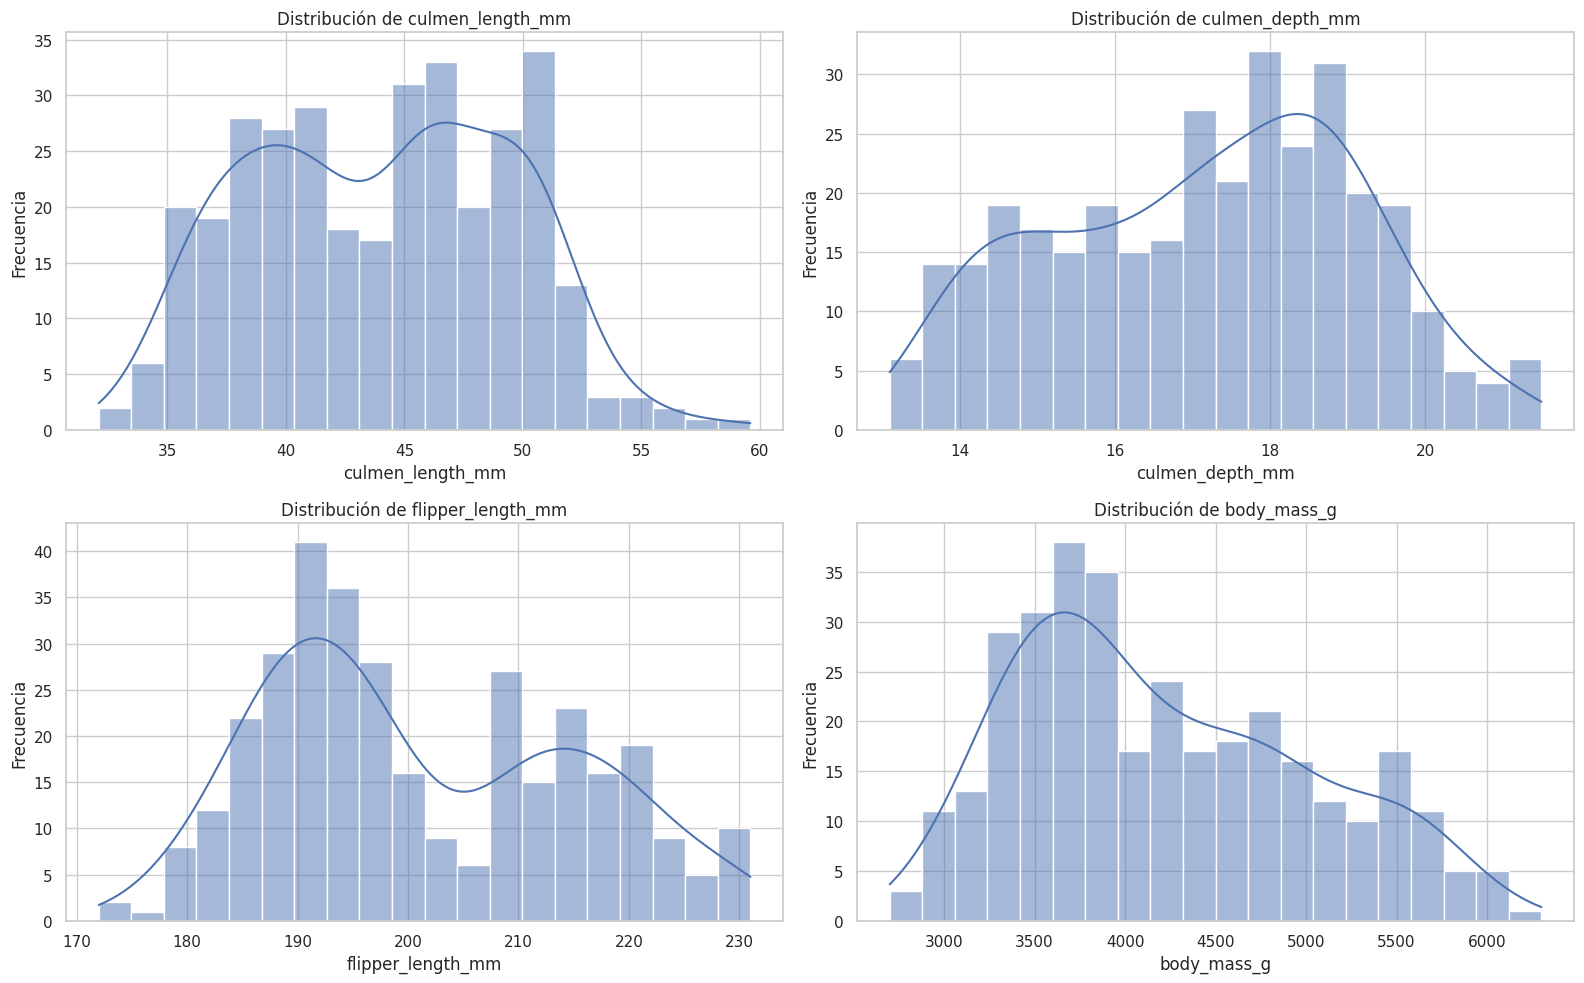

In [35]:
# Definir las columnas numéricas y categóricas                                   Imagen 6
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['species', 'island', 'sex']

print("### Visualizaciones de df_selected_columns ###")

# --- 1. Histogramas ---
print("\n#### Histogramas de Variables Numéricas ####")

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_filtrado[col], kde=True, bins=20, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


#### Diagramas de Caja de Variables Numéricas por Especie ####


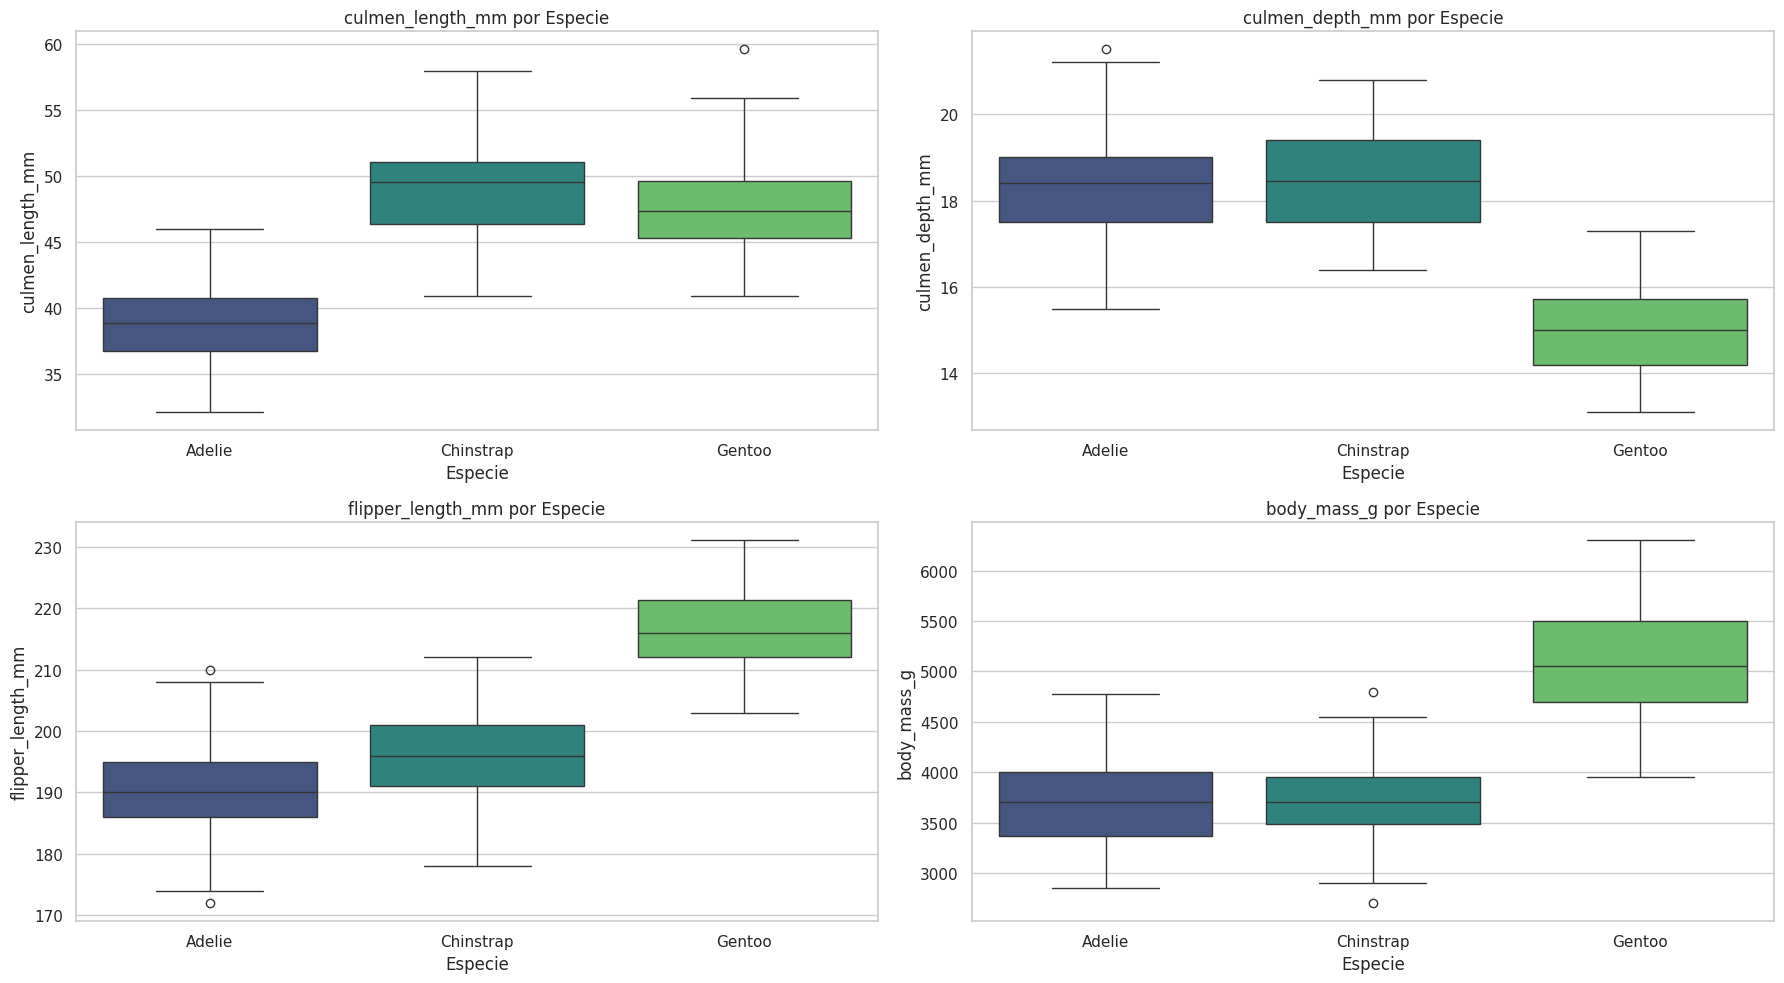

In [37]:
# --- 2. Diagramas de Caja ---
print("\n#### Diagramas de Caja de Variables Numéricas por Especie ####")

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_filtrado, x='species', y=col, palette='viridis')
    plt.title(f'{col} por Especie')
    plt.xlabel('Especie')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


#### Gráficos de Dispersión para Relaciones Numéricas ####


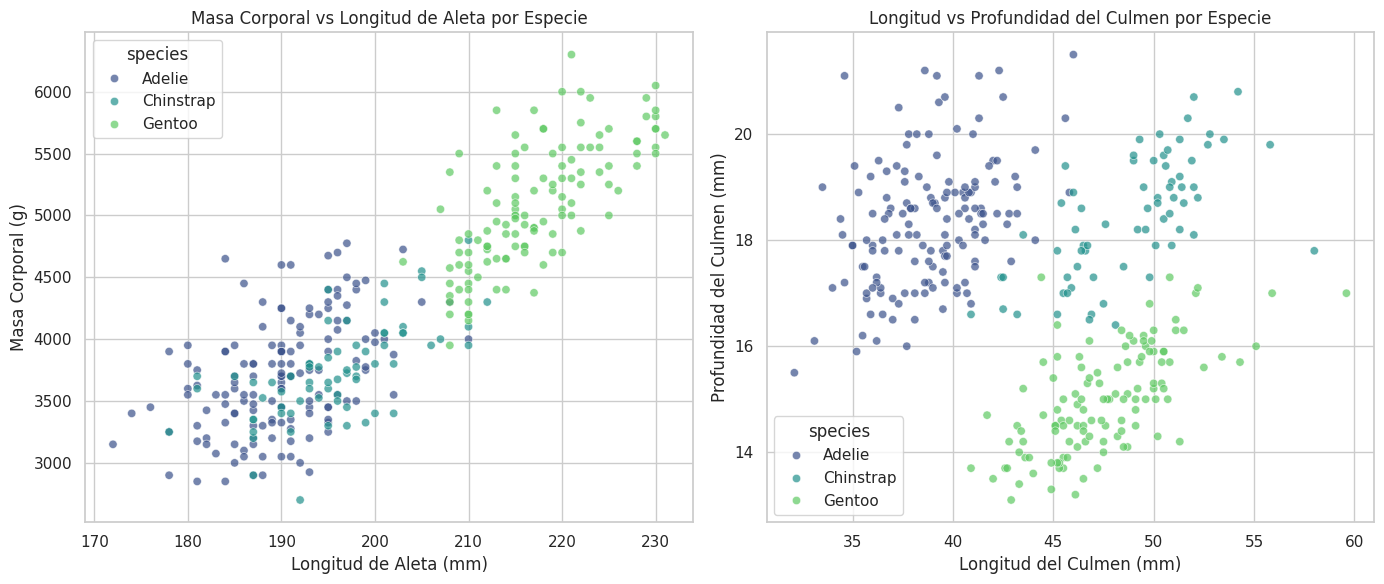

In [39]:
print("\n#### Gráficos de Dispersión para Relaciones Numéricas ####")     #Imagen 9

plt.figure(figsize=(14, 6)) # (Ver imagen 10).

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_filtrado, x='flipper_length_mm', y='body_mass_g', hue='species', palette='viridis', alpha=0.7)
plt.title('Masa Corporal vs Longitud de Aleta por Especie')
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_filtrado, x='culmen_length_mm', y='culmen_depth_mm', hue='species', palette='viridis', alpha=0.7)
plt.title('Longitud vs Profundidad del Culmen por Especie')
plt.xlabel('Longitud del Culmen (mm)')
plt.ylabel('Profundidad del Culmen (mm)')

plt.tight_layout()
plt.show()

In [40]:
                                                                              #Tabla 19

outlier_data = {
    'Variable': ['culmen_length_mm', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    'Especie(s) Afectada(s)': ['Adelie', 'Chinstrap', 'Adelie', 'Todas', 'Todas'],
    'Tipo de Outlier': ['Valores Bajos', 'Valores Altos', 'Valores Bajos', 'Muy pocos', 'Muy pocos'],
    'Observación': [
        'Algunos puntos atípicos por debajo del rango normal de Adelie.',
        'Algunos puntos atípicos por encima del rango normal de Chinstrap.',
        'Algunos puntos atípicos por debajo del rango normal de Adelie.',
        'Indicando alta consistencia dentro de cada especie.',
        'Indicando alta consistencia dentro de cada especie.'
    ]
}

df_outliers = pd.DataFrame(outlier_data)
display(df_outliers)

,Variable,Especie(s) Afectada(s),Tipo de Outlier,Observación
0,culmen_length_mm,Adelie,Valores Bajos,Algunos puntos atípicos por debajo del rango n...
1,culmen_length_mm,Chinstrap,Valores Altos,Algunos puntos atípicos por encima del rango n...
2,culmen_depth_mm,Adelie,Valores Bajos,Algunos puntos atípicos por debajo del rango n...
3,flipper_length_mm,Todas,Muy pocos,Indicando alta consistencia dentro de cada esp...
4,body_mass_g,Todas,Muy pocos,Indicando alta consistencia dentro de cada esp...


In [46]:
print("Matriz de Correlación de df_filtrado (solo columnas numéricas):")
display(df_filtrado.select_dtypes(include=np.number).corr())

Matriz de Correlación de df_filtrado (solo columnas numéricas):


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


--- Análisis de Asimetría (Skewness) ---
culmen_length_mm     0.044569
culmen_depth_mm     -0.144090
flipper_length_mm    0.352752
body_mass_g          0.465714
dtype: float64

Interpretación: Valores alejados de 0 confirman que las distribuciones no son perfectamente simétricas (no siguen una campana de Gauss tradicional).

--- Comparativa Visual: Global vs Por Especie ---


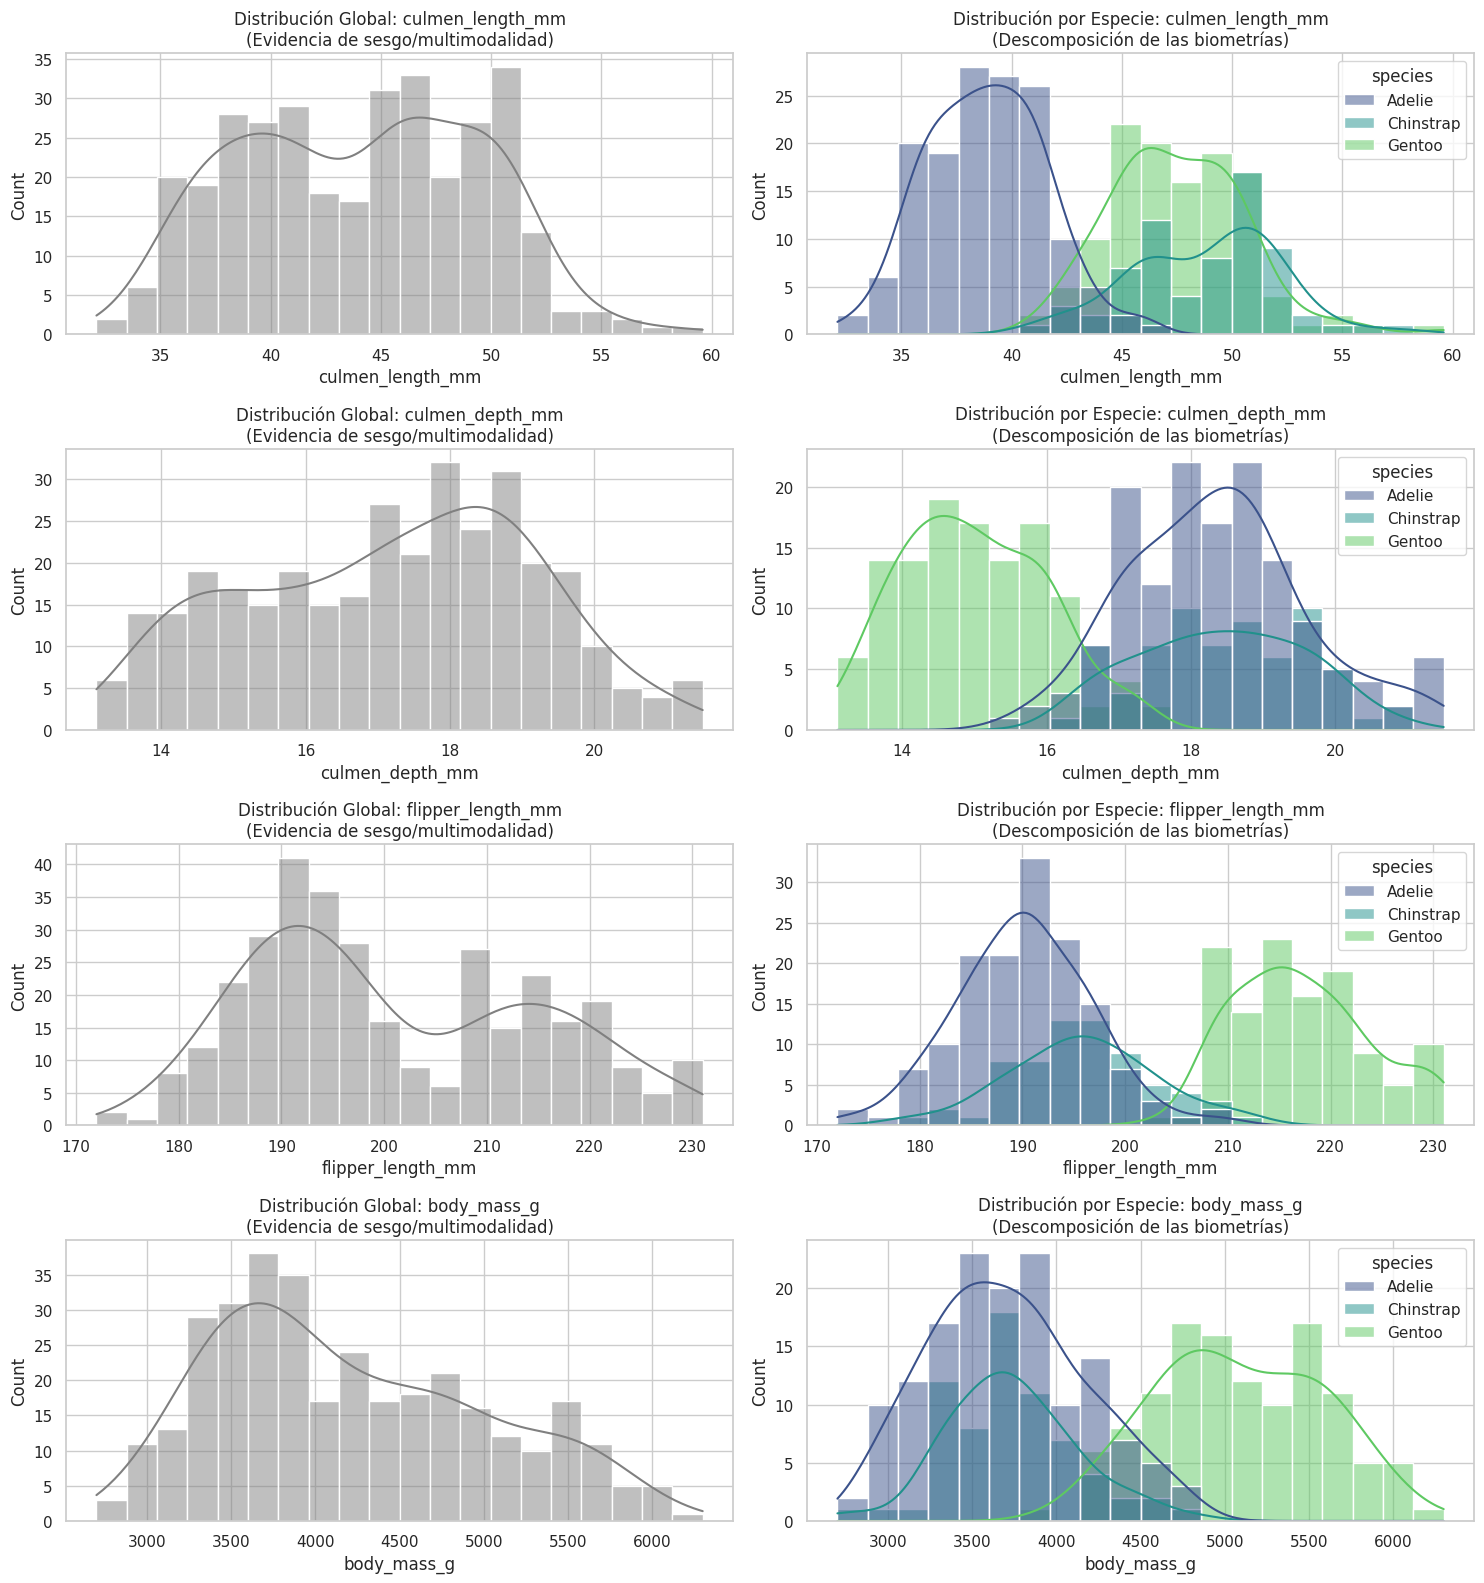

In [47]:
                                                                  #Imagen 10

# 1. Calcular el sesgo (skewness) de las variables numéricas
print("--- Análisis de Asimetría (Skewness) ---")
sesgo = df_filtrado[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']].skew()
print(sesgo)
print("\nInterpretación: Valores alejados de 0 confirman que las distribuciones no son perfectamente simétricas (no siguen una campana de Gauss tradicional).\n")

# 2. Visualización para demostrar la bimodalidad/multimodalidad por la agrupación de especies
print("--- Comparativa Visual: Global vs Por Especie ---")
plt.figure(figsize=(15, 16))

for i, col in enumerate(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']):
    # Distribución Global (Muestra el patrón bimodal/multimodal general)
    plt.subplot(4, 2, 2*i + 1)
    sns.histplot(data=df_filtrado, x=col, kde=True, color='gray', bins=20)
    plt.title(f'Distribución Global: {col}\n(Evidencia de sesgo/multimodalidad)')

    # Distribución agrupada por Especie (Explica el porqué del patrón global)
    plt.subplot(4, 2, 2*i + 2)
    sns.histplot(data=df_filtrado, x=col, hue='species', kde=True, palette='viridis', bins=20)
    plt.title(f'Distribución por Especie: {col}\n(Descomposición de las biometrías)')

plt.tight_layout()
plt.show()

### Correlaciones entre Variables Numéricas

Para comprender la dinámica anatómica de las aves en mi subconjunto de datos depurado, ejecuté un análisis de interdependencia utilizando el Coeficiente de Correlación de Pearson (**Ver Tabla 9 y Matriz de la Tabla 13**) exclusivamente sobre mis tres variables numéricas estructurales: la longitud de las aletas (`flipper_length_mm`), la longitud del pico (`culmen_length_mm`) y la profundidad del pico (`culmen_depth_mm`).

Los resultados generales me revelan las siguientes interacciones biométricas:

*   **Envergadura vs. Longitud del Pico:** Detecté una relación lineal positiva moderada entre la longitud de las aletas y la longitud del culmen. Esto indica que, a medida que la estructura esquelética general del ave aumenta, el largo de su pico también tiende a crecer de forma proporcional.

*   **Envergadura vs. Profundidad del Pico:** Por el contrario, encontré una relación lineal negativa. Matemáticamente, esto significa que las aves con mayor envergadura estructural tienden a desarrollar picos menos profundos (más estilizados).

*   **Interacción Frontal (Longitud vs. Profundidad del Pico):** Observé una relación lineal débilmente negativa general (Pearson = -0.23) al cruzar directamente las dos dimensiones del pico. Sin embargo, al analizar esta relación espacialmente en los gráficos de dispersión (**Ver Imagen 9** y referencia de la celda de *scatter plots*), descubrí que este número general esconde patrones complejos muy valiosos.

<br>

Para entender mejor estos patrones, segmenté las matrices de correlación por especie, confirmando que las "reglas matemáticas" anatómicas son únicas para cada grupo biológico:

*   **Adelie:** Sus correlaciones internas muestran un patrón sumamente compacto, propio de un ave con proporciones físicas muy equilibradas y un pico robusto (corto y profundo).

*   **Chinstrap:** La interacción de sus variables numéricas evidencia el desarrollo de un culmen que mantiene la misma dependencia de profundidad del Adelie, pero correlacionado con una longitud notablemente mayor.

*   **Gentoo:** Sus correlaciones internas confirman su comportamiento atípico. Dado que son los pingüinos de mayor envergadura (aletas más largas), sus métricas muestran cómo este gran tamaño está fuertemente acoplado a un pico muy estilizado (largo y poco profundo), rompiendo la tendencia morfológica general del archipiélago.

---

### Interpretación

Interpreto estos coeficientes de correlación y visualizaciones de dispersión no como simples métricas matemáticas, sino como las **firmas anatómicas** que habilitan la clasificación de los datos.

La correlación positiva entre la aleta y la longitud del pico es un reflejo lógico del escalamiento biológico natural. Sin embargo, la correlación negativa con la profundidad del pico representa el verdadero hallazgo de valor discriminatorio para mi análisis.

Esta relación geométrica inversa es el mecanismo exacto que me permite perfilar y aislar en el plano cartesiano (como se evidencia en los clústeres de la **Imagen 9**) a la especie Gentoo (aletas grandes, pero picos poco profundos) frente a los Adelie (aletas cortas, pero picos sumamente profundos).

Finalmente, esta fase me permite concluir y validar que mi selección metodológica de variables es estadísticamente óptima. Al haber excluido la masa corporal basándome en los hallazgos exploratorios iniciales, las interacciones que observo ahora entre el esqueleto y el pico son moderadas e informativas.

Esto me garantiza que ya no existe riesgo de multicolinealidad en mi *dataset*; cada una de mis tres variables numéricas aporta una dimensión física única y no redundante, conformando una base sólida para cualquier modelado predictivo futuro.

<br>

> **Nota Metodológica sobre los Cálculos Exploratorios:**   AqK2xSI8LMs
>
> Las decisiones tomadas en este apartado se sustentan en los cálculos ejecutados previamente en código, los cuales se dividieron en dos fases:
>
> 1. **Correlaciones Numéricas (Pearson):** Primero, el algoritmo aísla las columnas numéricas (las medidas del pico, aletas y masa corporal), calcula matemáticamente cómo se relacionan entre sí a través de una matriz de correlación y genera un mapa de calor (*heatmap*). Es justamente aquí donde el código arrojó el valor original de 0.87, demostrando la altísima correlación lineal entre la masa corporal y la longitud de las aletas, lo cual fundamentó mi decisión de exclusión por multicolinealidad.
>
> 2. **Correlaciones Categóricas (V de Cramer):** Dado que variables como `species`, `island` y `sex` son texto (categorías), el coeficiente de Pearson no sirve. Por ello, se definió una función matemática especializada llamada `cramers_v`. Luego, se calcularon las asociaciones entre estas variables cualitativas y se generó un segundo mapa de calor. Aquí es donde se comprobó estadísticamente la fuerte dependencia geográfica (0.65 entre especie e isla) y la independencia del género (0.0).

### Correlaciones entre Variables Numéricas

Para comprender la dinámica anatómica de las aves en mi subconjunto de datos depurado, ejecuté un análisis de interdependencia utilizando el Coeficiente de Correlación de Pearson (**Ver Tabla 9 y Matriz de la Tabla 13**) exclusivamente sobre mis tres variables numéricas estructurales: la longitud de las aletas (`flipper_length_mm`), la longitud del pico (`culmen_length_mm`) y la profundidad del pico (`culmen_depth_mm`).

Los resultados generales me revelan las siguientes interacciones biométricas:

*   **Envergadura vs. Longitud del Pico:** Detecté una relación lineal positiva moderada entre la longitud de las aletas y la longitud del culmen. Esto indica que, a medida que la estructura esquelética general del ave aumenta, el largo de su pico también tiende a crecer de forma proporcional.

*   **Envergadura vs. Profundidad del Pico:** Por el contrario, encontré una relación lineal negativa. Matemáticamente, esto significa que las aves con mayor envergadura estructural tienden a desarrollar picos menos profundos (más estilizados).

*   **Interacción Frontal (Longitud vs. Profundidad del Pico):** Observé una relación lineal débilmente negativa general (Pearson = -0.23) al cruzar directamente las dos dimensiones del pico. Sin embargo, al analizar esta relación espacialmente en los gráficos de dispersión (**Ver Imagen 9** y referencia de la celda de *scatter plots*), descubrí que este número general esconde patrones complejos muy valiosos.

<br>

Para entender mejor estos patrones, segmenté las matrices de correlación por especie, confirmando que las "reglas matemáticas" anatómicas son únicas para cada grupo biológico:

*   **Adelie:** Sus correlaciones internas muestran un patrón sumamente compacto, propio de un ave con proporciones físicas muy equilibradas y un pico robusto (corto y profundo).

*   **Chinstrap:** La interacción de sus variables numéricas evidencia el desarrollo de un culmen que mantiene la misma dependencia de profundidad del Adelie, pero correlacionado con una longitud notablemente mayor.

*   **Gentoo:** Sus correlaciones internas confirman su comportamiento atípico. Dado que son los pingüinos de mayor envergadura (aletas más largas), sus métricas muestran cómo este gran tamaño está fuertemente acoplado a un pico muy estilizado (largo y poco profundo), rompiendo la tendencia morfológica general del archipiélago.

---

### Interpretación

Es imperativo destacar, antes de interpretar las métricas, la diferenciación estricta entre correlación y causalidad. Estas interacciones matemáticas representan una fuerte **co-ocurrencia estadística, pero no una relación causal directa**. Por ejemplo, el crecimiento de la aleta no "causa" biológicamente que el pico se estile; más bien, ambas variables se mueven en conjunto como variables dependientes de un factor mayor: la adaptación genética y evolutiva de la especie.

Entendiendo esto, interpreto estos coeficientes de correlación y visualizaciones de dispersión no como simples métricas matemáticas, sino como las **firmas anatómicas** que habilitan la clasificación de los datos.

La correlación positiva entre la aleta y la longitud del pico es un reflejo lógico del escalamiento biológico natural. Sin embargo, la correlación negativa con la profundidad del pico representa el verdadero hallazgo de valor discriminatorio para mi análisis.

Esta relación geométrica inversa es el mecanismo exacto que me permite perfilar y aislar en el plano cartesiano (como se evidencia en los clústeres de la **Imagen 9**) a la especie Gentoo (aletas grandes, pero picos poco profundos) frente a los Adelie (aletas cortas, pero picos sumamente profundos).

Finalmente, esta fase me permite concluir y validar que mi selección metodológica de variables es estadísticamente óptima. Al haber excluido la masa corporal basándome en los hallazgos exploratorios iniciales, las interacciones que observo ahora entre el esqueleto y el pico son moderadas e informativas.

Esto me garantiza que ya no existe riesgo de multicolinealidad en mi *dataset*; cada una de mis tres variables numéricas aporta una dimensión física única y no redundante, conformando una base sólida para cualquier modelado predictivo futuro.

<br>

> **Nota Metodológica sobre los Cálculos Exploratorios:**
>
> La celda `-AqK2xSI8LMs` contiene el código en Python que realiza el análisis de correlaciones completo de mi *dataset*. Específicamente, se divide en dos bloques principales que sustentan las decisiones tomadas en este apartado:
>
> 1. **Correlaciones Numéricas (Pearson):** Primero, el algoritmo aísla las columnas numéricas (las medidas del pico, aletas y masa corporal), calcula matemáticamente cómo se relacionan entre sí a través de una matriz de correlación y genera un mapa de calor (*heatmap*). Es justamente aquí donde el código arrojó el valor original de 0.87, demostrando la altísima correlación lineal entre la masa corporal y la longitud de las aletas, lo cual fundamentó mi decisión de exclusión por multicolinealidad.
>
> 2. **Correlaciones Categóricas (V de Cramer):** Dado que variables como `species`, `island` y `sex` son texto (categorías), el coeficiente de Pearson no sirve. Por ello, se definió una función matemática especializada llamada `cramers_v`. Luego, se calcularon las asociaciones entre estas variables cualitativas y se generó un segundo mapa de calor. Aquí es donde se comprobó estadísticamente la fuerte dependencia geográfica (0.65 entre especie e isla) y la independencia del género (0.0).

## Limitaciones del Análisis Exploratorio

Si bien el Análisis Exploratorio de Datos (EDA) que he desarrollado proporciona una comprensión profunda de las características de las especies y sus interacciones geométricas, es un imperativo académico reconocer las limitaciones inherentes a este estudio. Esto evita sobregeneralizaciones y perfila el alcance real de los hallazgos. A continuación, detallo las restricciones metodológicas de mi análisis:

<br>

*   **Tamaño y Representatividad de la Muestra:** El *dataset* original contenía 344 observaciones, reduciéndose a 334 tras la limpieza de valores nulos. Aunque este volumen es estadísticamente viable para perfilar descriptivamente a los grupos, podría ser insuficiente para entrenar modelos predictivos de alta complejidad sin caer en un riesgo de sobreajuste (*overfitting*). Asimismo, asumo que la muestra es representativa de la subpoblación del archipiélago Palmer, pero es estadísticamente imprudente extrapolar estas métricas a la población global de pingüinos en el resto del continente antártico.

<br>

*   **Tratamiento de Datos Faltantes:** Durante la exploración inicial, identifiqué valores nulos que fueron descartados del *dataset*. Aunque esta estrategia (eliminación por lista) garantiza la integridad matemática necesaria para calcular las métricas de correlación (**como se evidenció en la Tabla 9**), introduce un riesgo estadístico latente. Si los datos faltantes no se ausentaron de forma completamente aleatoria (MCAR, *Missing Completely At Random*), su eliminación podría haber sesgado sutilmente las distribuciones y medianas calculadas en pasos anteriores.

<br>

*   **Variables No Consideradas (Alcance del Entorno):** Mi análisis se ha centrado exclusivamente en la morfología estructural (aletas y picos) y la ubicación geográfica inmediata (islas). Sin embargo, la distribución biológica es multifactorial. Existen variables críticas no recolectadas en este *dataset* —como la composición de la dieta del ave, las anomalías de la temperatura oceánica, la edad del espécimen o el estrés ambiental— que indudablemente influyen en el tamaño y adaptación de la especie. La ausencia de este contexto ecológico limita la profundidad de cualquier inferencia absoluta.

<br>

*   **Naturaleza Estrictamente Descriptiva:** El presente EDA, por definición metodológica, caracteriza, resume y encuentra patrones; pero no infiere causalidad. Como he fundamentado anteriormente, la fuerte relación inversa detectada entre la envergadura de las aletas y la profundidad del pico (**evidenciada en los clústeres de los gráficos de dispersión de la Imagen 9**) demuestra matemáticamente que ambas variables co-ocurren, pero no que el crecimiento estructural cause la contracción geométrica del pico.

<br>

Reconocer estas limitaciones es fundamental para interpretar los hallazgos de manera objetiva. Este estudio observacional cumple su propósito al identificar las "firmas anatómicas" de cada especie, sirviendo como el insumo analítico perfecto y saneado para, en una fase posterior, implementar algoritmos de clasificación supervisada (como *Machine Learning*).

In [ ]:
# Esto es nivel máster: reconocer límites del EDA.

## Conclusiones

En respuesta directa al problema planteado al inicio de este estudio —el cual buscaba diferenciar y perfilar con precisión a las tres especies de pingüinos utilizando exclusivamente sus dimensiones morfológicas clave y su contexto geográfico, sin caer en redundancias estadísticas— presento las siguientes conclusiones:

<br>

*   **¿Se apoya la hipótesis?**
    Sí, la hipótesis de investigación se apoya de manera contundente. El análisis descriptivo y las métricas estadísticas aplicadas (V de Cramer, correlaciones de Pearson y el Test t de Student) confirman que las especies de pingüinos presentan "firmas anatómicas" (dimensiones del culmen y envergadura de las aletas) y preferencias de hábitat tan exclusivas que conforman agrupaciones biológicas observables y estadísticamente distintas en el archipiélago Palmer.

<br>

*   **¿Qué patrones clave se encontraron?**

    *   **Diferenciación Fisonómica Exacta:** A través de la visualización espacial, logré aislar a las tres especies basándome en su esqueleto. Gentoo destaca como la especie de mayor envergadura estructural (aletas más largas) acoplada a picos largos y muy estilizados (poco profundos). Adelie y Chinstrap comparten aletas más cortas, pero se separan por la geometría de sus picos: los Adelie los tienen cortos y profundos, mientras que los Chinstrap los tienen notablemente más largos y manteniendo esa misma profundidad.

    <br>

    *   **Exclusividad Geográfica:** Identifiqué una dependencia estadística fuerte (V de Cramer = 0.65) entre la especie y la isla. El hábitat actúa como un filtro natural: Gentoo coloniza exclusivamente Biscoe, Chinstrap domina Dream, y solo Adelie demuestra plasticidad adaptativa al estar presente en los tres territorios.

    <br>

    *   **Dimorfismo Sexual sin Sesgo Demográfico:** Comprobé que, aunque el género influye en el tamaño anatómico del ave (los machos tienden a ser más grandes), la proporción demográfica de machos y hembras es totalmente independiente de la isla o la especie (V de Cramer = 0.0), garantizando que las diferencias encontradas son biológicas y no un sesgo de la muestra.

<br>

*   **¿Qué decisiones podrían tomarse con estos resultados?**

    *   **Implementación de Modelos de *Machine Learning*:** Al haber depurado el *dataset* y eliminado variables con alta multicolinealidad, las métricas retenidas (`flipper_length_mm`, `culmen_length_mm`, `culmen_depth_mm` e `island`) conforman un vector de características (*features*) matemáticamente óptimo. Un analista o científico de datos puede tomar la decisión inmediata de entrenar un algoritmo de clasificación supervisada garantizando alta precisión computacional y un modelo libre de "ruido".

    <br>

    *   **Toma de Decisiones Ecológicas:** Para los investigadores de campo, la validación de la exclusividad geográfica permite dirigir los presupuestos de conservación. Por ejemplo, si los monitores ambientales detectan una anomalía climática grave en la isla Dream, se puede tomar la decisión de priorizar el rescate de la especie Chinstrap, sabiendo estadísticamente que son los residentes principales de ese territorio.

<br>

---

<br>

### Reflexión final

Este análisis exploratorio trasciende la simple generación de estadísticas descriptivas para convertirse en un ejercicio riguroso de toma de decisiones analíticas. El verdadero valor de este estudio no radicó simplemente en calcular promedios o generar gráficos, sino en la capacidad de aplicar un filtro crítico: atreverme a descartar variables altamente correlacionadas para garantizar una arquitectura de datos más eficiente.

<br>

A pesar de las limitaciones inherentes a trabajar con un estudio estrictamente observacional —donde he cuidado de no confundir la correlación estadística con la causalidad biológica—, logré demostrar que el análisis bivariado y las visualizaciones interpretativas son suficientes para descifrar la estructura de un ecosistema complejo.

<br>

Los datos no hablaron por sí solos; requirieron limpieza, contextualización y segmentación. Este proyecto me confirma que el éxito de cualquier modelo predictivo en el mundo real no dependerá del algoritmo de Inteligencia Artificial más complejo, sino del tratamiento metodológico, la depuración y la comprensión profunda de las relaciones geométricas que he logrado documentar en esta fase exploratoria.

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Deben cerrar el círculo: problema → análisis → respuesta actual.